# VGG16 + MobileNetV2 Early Fusion — Same Code, Patient-Level, 35 Epochs

This notebook is based directly on the uploaded
**VGG16 + MobileNetV2 Early Fusion — Stable Full-Epochs Fixed** notebook.

## Kept the same from the uploaded notebook

- VGG16 + MobileNetV2 concatenation architecture
- VGG16 + MobileNetV2 attention architecture
- `include_top=False` for both backbones
- Same stable training and checkpoint-recovery design
- Same serializable preprocessing and attention layers
- Same training-curve plotting logic
- Same slice-level and patient-level evaluation functions
- Same Grad-CAM strategy and branch-wise Grad-CAM engine
- Same artifact naming style for compatibility
- Same patient-level split logic and split-fingerprint logic
- Same ROC `.npz` output structure
- Same confusion-matrix, report, summary, and verification workflow

## Updated for this version

- Concatenation: **35 total epochs**
- Attention: **35 total epochs**
- Stage 1 frozen-backbone training: **10 epochs**
- Stage 2 fine-tuning: **25 epochs**
- Total per fusion model: **35 epochs**
- Total when both fusion models finish: **70 model-training epochs**

Because `USE_EARLY_STOPPING = False`, both fusion models are scheduled to
run their full configured epoch counts unless training is interrupted by
an external issue such as Colab disconnects.

In [2]:

# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================
from google.colab import drive
drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# ============================================================
# 2. IMPORTS, GPU SETUP, AND REPRODUCIBILITY
# ============================================================
import os
import re
import gc
import glob
import json
import math
import shutil
import zipfile
import hashlib
import traceback
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16, MobileNetV2
from tensorflow.keras.applications.vgg16 import (
    preprocess_input as vgg16_preprocess
)
from tensorflow.keras.applications.mobilenet_v2 import (
    preprocess_input as mobilenet_preprocess
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split, StratifiedGroupKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)
from sklearn.utils.class_weight import compute_class_weight

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")
print("Available GPUs:", gpus)

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled.")
    except RuntimeError as error:
        print("GPU configuration warning:", error)
else:
    print(
        "WARNING: No GPU was detected. Dual-backbone training will be slow."
    )

TensorFlow version: 2.20.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU memory growth enabled.


In [4]:
# ============================================================
# 3. PATHS AND SETTINGS
# ============================================================
# Change ZIP_PATH only when the dataset is stored elsewhere.

ZIP_PATH = Path(
    "/content/drive/MyDrive/Patient_level_classification/Early_fusion_/VGG16_mobilenet_early_fusion_patient_level/VGG16_mobilenet_dataset_here/Parkinson_dataset.zip"
)

UNZIP_DIR = Path(
    "/content/drive/MyDrive/Patient_level_classification/Early_fusion_/VGG16_mobilenet_early_fusion_patient_level/VGG16_mobilenet_dataset_unzip_here"
)

DATASET_ROOT = UNZIP_DIR / "Parkinson_dataset"

ROOT_OUTPUT_DIR = Path(
    "/content/drive/MyDrive/Patient_level_classification/Early_fusion_/VGG16_mobilenet_early_fusion_patient_level/VGG16_mobilenet_data_save_here"
)
ROOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 8
SEED = 42

# Patient-level split
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# Full training schedule
HEAD_EPOCHS = 10
FINE_TUNE_EPOCHS = 25

HEAD_LEARNING_RATE = 1e-4
FINE_TUNE_LEARNING_RATE = 5e-6

UNFREEZE_VGG_LAST_N = 8
UNFREEZE_MOBILE_LAST_N = 20

# Early stopping was the reason training ended before all configured epochs.
# Keep this False to run the complete schedule.
USE_EARLY_STOPPING = False
EARLY_STOPPING_PATIENCE = 8

# ReduceLROnPlateau lowers the learning rate but does not stop training.
REDUCE_LR_PATIENCE = 3
REDUCE_LR_FACTOR = 0.5
MIN_LEARNING_RATE = 1e-7

# BackupAndRestore saves recovery data after each epoch.
ENABLE_EPOCH_BACKUP = True

TOTAL_EPOCHS_PER_MODEL = (
    HEAD_EPOCHS + FINE_TUNE_EPOCHS
)

assert TOTAL_EPOCHS_PER_MODEL == 35

# Use a new experiment tag to avoid accidentally loading old partial files.
EXPERIMENT_TAG = "stable_full_epochs_v2"

CONCAT_PREFIX = (
    "vgg16_mobilenet_early_fusion_"
    f"concatenation_{EXPERIMENT_TAG}"
)

ATTENTION_PREFIX = (
    "vgg16_mobilenet_early_fusion_"
    f"attention_{EXPERIMENT_TAG}"
)

# Fresh run is safest. Set to True only after a fully completed new run.
REUSE_COMPLETED_MODELS = False

# When Stage 1 has completed but Stage 2 was interrupted, this can reuse
# the saved Stage 1 model instead of repeating Stage 1.
REUSE_SAVED_STAGE1 = True

RUN_CONCATENATION_MODEL = True
RUN_ATTENTION_MODEL = True

print("ZIP_PATH:", ZIP_PATH)
print("DATASET_ROOT:", DATASET_ROOT)
print("ROOT_OUTPUT_DIR:", ROOT_OUTPUT_DIR)
print("Concatenation prefix:", CONCAT_PREFIX)
print("Attention prefix:", ATTENTION_PREFIX)
print("USE_EARLY_STOPPING:", USE_EARLY_STOPPING)

ZIP_PATH: /content/drive/MyDrive/Patient_level_classification/Early_fusion_/VGG16_mobilenet_early_fusion_patient_level/VGG16_mobilenet_dataset_here/Parkinson_dataset.zip
DATASET_ROOT: /content/drive/MyDrive/Patient_level_classification/Early_fusion_/VGG16_mobilenet_early_fusion_patient_level/VGG16_mobilenet_dataset_unzip_here/Parkinson_dataset
ROOT_OUTPUT_DIR: /content/drive/MyDrive/Patient_level_classification/Early_fusion_/VGG16_mobilenet_early_fusion_patient_level/VGG16_mobilenet_data_save_here
Concatenation prefix: vgg16_mobilenet_early_fusion_concatenation_stable_full_epochs_v2
Attention prefix: vgg16_mobilenet_early_fusion_attention_stable_full_epochs_v2
USE_EARLY_STOPPING: False


In [5]:

# ============================================================
# 4. UNZIP DATASET
# ============================================================
if not ZIP_PATH.exists():
    raise FileNotFoundError(
        f"ZIP file not found:\n{ZIP_PATH}\n"
        "Update ZIP_PATH in the previous cell."
    )

UNZIP_DIR.mkdir(parents=True, exist_ok=True)

if not DATASET_ROOT.exists() or not any(DATASET_ROOT.iterdir()):
    print("Extracting dataset...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(UNZIP_DIR)
    print("Extraction completed:", UNZIP_DIR)
else:
    print("Dataset already extracted:", DATASET_ROOT)

if not DATASET_ROOT.exists():
    raise FileNotFoundError(
        f"Expected extracted folder not found:\n{DATASET_ROOT}"
    )


Dataset already extracted: /content/drive/MyDrive/Patient_level_classification/Early_fusion_/VGG16_mobilenet_early_fusion_patient_level/VGG16_mobilenet_dataset_unzip_here/Parkinson_dataset


In [6]:

# ============================================================
# 5. DISCOVER IMAGES AND EXTRACT PATIENT INFORMATION
# ============================================================
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

def infer_class(path):
    lower_path = str(path).lower()

    if any(token in lower_path for token in ["healthy", "normal", "control"]):
        return 0, "Healthy"

    if any(token in lower_path for token in ["parkinson", "pd_dataset", "/pd/", "\\pd\\"]):
        return 1, "Parkinson"

    return None, None


def extract_patient_id(path):
    filename = Path(path).name

    match = re.search(r"PPMI[_-](\d+)", filename, flags=re.IGNORECASE)
    if match:
        return match.group(1)

    # Stable fallback when a PPMI numeric ID is unavailable.
    stem = re.sub(
        r"_slice[_-]?\d+.*$",
        "",
        Path(path).stem,
        flags=re.IGNORECASE
    )
    return stem[:100]


def extract_slice_index(path):
    filename = Path(path).stem

    patterns = [
        r"_slice[_-]?(\d+)",
        r"_sl[_-]?(\d+)",
        r"[_-](\d{1,4})$"
    ]

    for pattern in patterns:
        match = re.search(pattern, filename, flags=re.IGNORECASE)
        if match:
            return float(match.group(1))

    return np.nan


records = []

for path in DATASET_ROOT.rglob("*"):
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
        label, class_name = infer_class(path)

        if label is not None:
            records.append({
                "image_path": str(path),
                "filename": path.name,
                "patient_id": extract_patient_id(path),
                "slice_index": extract_slice_index(path),
                "label": int(label),
                "class_name": class_name
            })

df = pd.DataFrame(records)

if df.empty:
    raise ValueError(
        "No labeled images were found. Check DATASET_ROOT and folder names."
    )

print("Total discovered images:", len(df))
print(df["class_name"].value_counts())
print("Unique patients:", df["patient_id"].nunique())

patient_label_counts = df.groupby("patient_id")["label"].nunique()
mixed_patients = patient_label_counts[patient_label_counts > 1]

if len(mixed_patients) > 0:
    raise ValueError(
        "The same patient ID appears in both classes. Examples: "
        f"{mixed_patients.index[:10].tolist()}"
    )

display(df.head())


Total discovered images: 11120
class_name
Healthy      5560
Parkinson    5560
Name: count, dtype: int64
Unique patients: 52


,image_path,filename,patient_id,slice_index,label,class_name
0,/content/drive/MyDrive/Patient_level_classific...,PPMI_153233_MR_SAG_3D_T1-weighted_br_raw_20230...,153233,NaN,0,Healthy
1,/content/drive/MyDrive/Patient_level_classific...,PPMI_153233_MR_SAG_3D_T1-weighted_br_raw_20230...,153233,NaN,0,Healthy
2,/content/drive/MyDrive/Patient_level_classific...,PPMI_153233_MR_SAG_3D_T1-weighted_br_raw_20230...,153233,NaN,0,Healthy
3,/content/drive/MyDrive/Patient_level_classific...,PPMI_153233_MR_SAG_3D_T1-weighted_br_raw_20230...,153233,NaN,0,Healthy
4,/content/drive/MyDrive/Patient_level_classific...,PPMI_153233_MR_SAG_3D_T1-weighted_br_raw_20230...,153233,NaN,0,Healthy


In [7]:
# ============================================================
# 7. INCLUDE ALL IMAGES IN THE EXPERIMENT
# ============================================================
selected_df = df.copy().reset_index(drop=True)

# All images are selected by default.
selected_df["selected_for_experiment"] = True

if len(selected_df) != len(df):
    raise RuntimeError(
        f"All-image inclusion failed: discovered={len(df)}, "
        f"selected={len(selected_df)}"
    )

if not selected_df["selected_for_experiment"].all():
    raise RuntimeError("Some images were unexpectedly excluded.")

print("Total discovered images:", len(df))
print("Total images included in experiment:", len(selected_df))
print("Images excluded from experiment:", len(df) - len(selected_df))
print("Unique patients included:", selected_df["patient_id"].nunique())
print("\nClass distribution:")
print(selected_df["class_name"].value_counts())

patient_counts = (
    selected_df.groupby(["patient_id", "class_name"])
               .size()
               .reset_index(name="included_slices")
)

display(patient_counts.head(10))

all_images_manifest_path = (
    ROOT_OUTPUT_DIR
    / "vgg16_mobilenet_all_images_experiment_manifest.csv"
)

selected_df.to_csv(
    all_images_manifest_path,
    index=False
)

print("Saved:", all_images_manifest_path)

assert len(selected_df) == len(df)
assert int(selected_df["selected_for_experiment"].sum()) == len(df)

print("\nALL-IMAGE INCLUSION CHECK: PASSED")

Total discovered images: 11120
Total images included in experiment: 11120
Images excluded from experiment: 0
Unique patients included: 52

Class distribution:
class_name
Healthy      5560
Parkinson    5560
Name: count, dtype: int64


,patient_id,class_name,included_slices
0,100001,Parkinson,192
1,100017,Parkinson,192
2,100738,Parkinson,188
3,100878,Parkinson,192
4,100889,Parkinson,192
5,100890,Healthy,192
6,100898,Parkinson,192
7,100905,Parkinson,188
8,100911,Parkinson,192
9,100952,Parkinson,192


Saved: /content/drive/MyDrive/Patient_level_classification/Early_fusion_/VGG16_mobilenet_early_fusion_patient_level/VGG16_mobilenet_data_save_here/vgg16_mobilenet_all_images_experiment_manifest.csv

ALL-IMAGE INCLUSION CHECK: PASSED


In [8]:

# ============================================================
# 9. PATIENT-LEVEL TRAIN / VALIDATION / TEST SPLIT
# ============================================================
patient_df = (
    selected_df.groupby("patient_id", as_index=False)
               .agg(
                   label=("label", "first"),
                   class_name=("class_name", "first"),
                   selected_slices=("image_path", "count")
               )
)

train_patients, temp_patients = train_test_split(
    patient_df,
    test_size=(1.0 - TRAIN_RATIO),
    random_state=SEED,
    stratify=patient_df["label"]
)

relative_test_size = TEST_RATIO / (VAL_RATIO + TEST_RATIO)

val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=relative_test_size,
    random_state=SEED,
    stratify=temp_patients["label"]
)

split_map = {}

for patient_id in train_patients["patient_id"]:
    split_map[patient_id] = "train"

for patient_id in val_patients["patient_id"]:
    split_map[patient_id] = "val"

for patient_id in test_patients["patient_id"]:
    split_map[patient_id] = "test"

selected_df["split"] = selected_df["patient_id"].map(split_map)

train_patient_set = set(
    selected_df.loc[
        selected_df["split"] == "train",
        "patient_id"
    ]
)
val_patient_set = set(
    selected_df.loc[
        selected_df["split"] == "val",
        "patient_id"
    ]
)
test_patient_set = set(
    selected_df.loc[
        selected_df["split"] == "test",
        "patient_id"
    ]
)

assert train_patient_set.isdisjoint(val_patient_set)
assert train_patient_set.isdisjoint(test_patient_set)
assert val_patient_set.isdisjoint(test_patient_set)

print("Patient-overlap check: PASSED")

split_summary = (
    selected_df.groupby(["split", "class_name"])
               .agg(
                   images=("image_path", "count"),
                   patients=("patient_id", "nunique")
               )
               .reset_index()
)

display(split_summary)

split_manifest_path = (
    ROOT_OUTPUT_DIR
    / "vgg16_mobilenet_patient_level_split_manifest.csv"
)
selected_df.to_csv(split_manifest_path, index=False)
print("Saved:", split_manifest_path)


# Verify that every discovered image was assigned to exactly one split.
assigned_images = len(selected_df)
expected_images = len(df)

if assigned_images != expected_images:
    raise RuntimeError(
        f"Not all images were assigned: expected={expected_images}, "
        f"assigned={assigned_images}"
    )

if selected_df["split"].isna().any():
    raise RuntimeError("Some images have no train/validation/test split.")

print("\nALL IMAGES ASSIGNED TO A SPLIT:", assigned_images)
print("Excluded images:", expected_images - assigned_images)
print("All-image split assignment check: PASSED")


Patient-overlap check: PASSED


,split,class_name,images,patients
0,test,Healthy,1148,4
1,test,Parkinson,768,4
2,train,Healthy,3648,16
3,train,Parkinson,3832,20
4,val,Healthy,764,3
5,val,Parkinson,960,5


Saved: /content/drive/MyDrive/Patient_level_classification/Early_fusion_/VGG16_mobilenet_early_fusion_patient_level/VGG16_mobilenet_data_save_here/vgg16_mobilenet_patient_level_split_manifest.csv

ALL IMAGES ASSIGNED TO A SPLIT: 11120
Excluded images: 0
All-image split assignment check: PASSED


In [9]:

# ============================================================
# 10. SAVE FIVE-FOLD GROUP ASSIGNMENTS
# ============================================================
# This cell creates reproducible patient-level folds without training
# ten additional large fusion models.

fold_source = selected_df.copy()
fold_source["group_cv_fold"] = -1

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

for fold_number, (_, validation_indices) in enumerate(
    sgkf.split(
        fold_source,
        y=fold_source["label"],
        groups=fold_source["patient_id"]
    ),
    start=1
):
    fold_source.loc[
        fold_source.index[validation_indices],
        "group_cv_fold"
    ] = fold_number

fold_manifest_path = (
    ROOT_OUTPUT_DIR
    / "vgg16_mobilenet_five_fold_group_manifest.csv"
)
fold_source.to_csv(fold_manifest_path, index=False)

print("Saved:", fold_manifest_path)
print(
    fold_source.groupby(
        ["group_cv_fold", "class_name"]
    )["patient_id"].nunique()
)


Saved: /content/drive/MyDrive/Patient_level_classification/Early_fusion_/VGG16_mobilenet_early_fusion_patient_level/VGG16_mobilenet_data_save_here/vgg16_mobilenet_five_fold_group_manifest.csv
group_cv_fold  class_name
1              Healthy       5
               Parkinson     5
2              Healthy       6
               Parkinson     5
3              Healthy       3
               Parkinson     7
4              Healthy       5
               Parkinson     5
5              Healthy       4
               Parkinson     7
Name: patient_id, dtype: int64


In [10]:
# ============================================================
# 11. IMAGE GENERATORS
# ============================================================
train_df = (
    selected_df[selected_df["split"] == "train"]
    .copy()
    .reset_index(drop=True)
)

val_df = (
    selected_df[selected_df["split"] == "val"]
    .copy()
    .reset_index(drop=True)
)

test_df = (
    selected_df[selected_df["split"] == "test"]
    .copy()
    .reset_index(drop=True)
)

for frame in [train_df, val_df, test_df]:
    frame["label_string"] = frame["label"].astype(str)

train_datagen = ImageDataGenerator(
    rotation_range=8,
    zoom_range=0.08,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=False,
    fill_mode="nearest"
)

val_test_datagen = ImageDataGenerator()

train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="label_string",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True,
    seed=SEED,
    validate_filenames=True
)

val_gen = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="label_string",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False,
    validate_filenames=True
)

test_gen = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="label_string",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False,
    validate_filenames=True
)

print("Class indices:", train_gen.class_indices)

if train_gen.class_indices != {"0": 0, "1": 1}:
    raise RuntimeError(
        f"Unexpected class mapping: {train_gen.class_indices}"
    )

if bool(test_gen.shuffle):
    raise RuntimeError("The test generator must use shuffle=False.")

expected_test_paths = [
    os.path.abspath(path)
    for path in test_df["image_path"].astype(str)
]

generator_test_paths = [
    os.path.abspath(path)
    for path in test_gen.filepaths
]

if expected_test_paths != generator_test_paths:
    raise RuntimeError(
        "Test generator order does not match test_df order."
    )

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_df["label"].to_numpy(dtype=np.int32)
)

CLASS_WEIGHTS = {
    0: float(class_weights_array[0]),
    1: float(class_weights_array[1])
}

generator_total = (
    train_gen.samples
    + val_gen.samples
    + test_gen.samples
)

if generator_total != len(selected_df):
    raise RuntimeError(
        f"Generator total={generator_total}, "
        f"manifest total={len(selected_df)}"
    )

split_fingerprint_source = (
    selected_df[
        ["patient_id", "label", "split", "image_path"]
    ]
    .astype(str)
    .sort_values(
        ["patient_id", "split", "image_path"]
    )
)

SPLIT_FINGERPRINT = hashlib.sha256(
    pd.util.hash_pandas_object(
        split_fingerprint_source,
        index=False
    ).values.tobytes()
).hexdigest()[:20]

print("Class weights:", CLASS_WEIGHTS)
print("Training images:", train_gen.samples)
print("Validation images:", val_gen.samples)
print("Test images:", test_gen.samples)
print("Total images used:", generator_total)
print("Images excluded:", len(selected_df) - generator_total)
print("Split fingerprint:", SPLIT_FINGERPRINT)
print("Generator and prediction-order checks: PASSED")

Found 7480 validated image filenames belonging to 2 classes.
Found 1724 validated image filenames belonging to 2 classes.
Found 1916 validated image filenames belonging to 2 classes.
Class indices: {'0': 0, '1': 1}
Class weights: {0: 1.025219298245614, 1: 0.975991649269311}
Training images: 7480
Validation images: 1724
Test images: 1916
Total images used: 11120
Images excluded: 0
Split fingerprint: c71b457b294a42eb5939
Generator and prediction-order checks: PASSED


In [11]:

# ============================================================
# 12. SERIALIZABLE PREPROCESSING AND ATTENTION LAYERS
# ============================================================
@keras.utils.register_keras_serializable(package="ParkinsonMRI")
class VGG16Preprocess(layers.Layer):
    def call(self, inputs):
        return vgg16_preprocess(inputs)

    def get_config(self):
        return super().get_config()


@keras.utils.register_keras_serializable(package="ParkinsonMRI")
class MobileNetV2Preprocess(layers.Layer):
    def call(self, inputs):
        return mobilenet_preprocess(inputs)

    def get_config(self):
        return super().get_config()


@keras.utils.register_keras_serializable(package="ParkinsonMRI")
class SelectAttentionWeight(layers.Layer):
    def __init__(self, branch_index, **kwargs):
        super().__init__(**kwargs)
        self.branch_index = int(branch_index)

    def call(self, inputs):
        return inputs[:, self.branch_index:self.branch_index + 1]

    def get_config(self):
        config = super().get_config()
        config.update({"branch_index": self.branch_index})
        return config


In [12]:
# ============================================================
# 13. MODEL BUILDERS
# ============================================================
def compile_fusion_model(model, learning_rate):
    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate,
            clipnorm=1.0
        ),
        loss=keras.losses.BinaryCrossentropy(),
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="auc")
        ]
    )


def create_backbones(base_trainable=False):
    vgg_backbone = VGG16(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        name="vgg16_backbone"
    )
    vgg_backbone.trainable = base_trainable

    mobile_backbone = MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        name="mobilenetv2_backbone"
    )
    mobile_backbone.trainable = base_trainable

    return vgg_backbone, mobile_backbone


def build_concat_model(base_trainable=False):
    inputs = keras.Input(
        shape=(IMG_SIZE, IMG_SIZE, 3),
        name="mri_input"
    )

    vgg_input = VGG16Preprocess(
        name="vgg16_preprocessing"
    )(inputs)

    mobile_input = MobileNetV2Preprocess(
        name="mobilenetv2_preprocessing"
    )(inputs)

    vgg_backbone, mobile_backbone = create_backbones(
        base_trainable=base_trainable
    )

    vgg_features = vgg_backbone(
        vgg_input,
        training=False
    )
    mobile_features = mobile_backbone(
        mobile_input,
        training=False
    )

    vgg_vector = layers.GlobalAveragePooling2D(
        name="vgg16_gap"
    )(vgg_features)

    mobile_vector = layers.GlobalAveragePooling2D(
        name="mobilenetv2_gap"
    )(mobile_features)

    fused = layers.Concatenate(
        name="early_fusion_concatenation"
    )([vgg_vector, mobile_vector])

    x = layers.Dense(
        512,
        activation="relu",
        name="concat_dense_512"
    )(fused)
    x = layers.BatchNormalization(
        name="concat_bn_512"
    )(x)
    x = layers.Dropout(
        0.50,
        name="concat_dropout_512"
    )(x)

    x = layers.Dense(
        256,
        activation="relu",
        name="concat_dense_256"
    )(x)
    x = layers.BatchNormalization(
        name="concat_bn_256"
    )(x)
    x = layers.Dropout(
        0.40,
        name="concat_dropout_256"
    )(x)

    x = layers.Dense(
        128,
        activation="relu",
        name="concat_dense_128"
    )(x)
    x = layers.BatchNormalization(
        name="concat_bn_128"
    )(x)
    x = layers.Dropout(
        0.30,
        name="concat_dropout_128"
    )(x)

    outputs = layers.Dense(
        1,
        activation="sigmoid",
        dtype="float32",
        name="prediction"
    )(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="VGG16_MobileNetV2_Early_Fusion_Concatenation"
    )

    compile_fusion_model(
        model,
        HEAD_LEARNING_RATE
    )
    return model


def build_attention_model(base_trainable=False):
    inputs = keras.Input(
        shape=(IMG_SIZE, IMG_SIZE, 3),
        name="mri_input"
    )

    vgg_input = VGG16Preprocess(
        name="vgg16_preprocessing"
    )(inputs)

    mobile_input = MobileNetV2Preprocess(
        name="mobilenetv2_preprocessing"
    )(inputs)

    vgg_backbone, mobile_backbone = create_backbones(
        base_trainable=base_trainable
    )

    vgg_features = vgg_backbone(
        vgg_input,
        training=False
    )
    mobile_features = mobile_backbone(
        mobile_input,
        training=False
    )

    vgg_vector = layers.GlobalAveragePooling2D(
        name="vgg16_gap"
    )(vgg_features)

    mobile_vector = layers.GlobalAveragePooling2D(
        name="mobilenetv2_gap"
    )(mobile_features)

    vgg_projected = layers.Dense(
        256,
        activation="relu",
        name="vgg16_projected"
    )(vgg_vector)

    mobile_projected = layers.Dense(
        256,
        activation="relu",
        name="mobilenetv2_projected"
    )(mobile_vector)

    combined_features = layers.Concatenate(
        name="attention_input"
    )([vgg_projected, mobile_projected])

    attention_weights = layers.Dense(
        2,
        activation="softmax",
        name="branch_attention_weights"
    )(combined_features)

    vgg_weight = SelectAttentionWeight(
        0,
        name="vgg16_attention_weight"
    )(attention_weights)

    mobile_weight = SelectAttentionWeight(
        1,
        name="mobilenetv2_attention_weight"
    )(attention_weights)

    weighted_vgg = layers.Multiply(
        name="weighted_vgg16_features"
    )([vgg_projected, vgg_weight])

    weighted_mobile = layers.Multiply(
        name="weighted_mobilenetv2_features"
    )([mobile_projected, mobile_weight])

    fused = layers.Add(
        name="early_fusion_attention"
    )([weighted_vgg, weighted_mobile])

    x = layers.Dense(
        256,
        activation="relu",
        name="attention_dense_256"
    )(fused)
    x = layers.BatchNormalization(
        name="attention_bn_256"
    )(x)
    x = layers.Dropout(
        0.50,
        name="attention_dropout_256"
    )(x)

    x = layers.Dense(
        128,
        activation="relu",
        name="attention_dense_128"
    )(x)
    x = layers.BatchNormalization(
        name="attention_bn_128"
    )(x)
    x = layers.Dropout(
        0.30,
        name="attention_dropout_128"
    )(x)

    outputs = layers.Dense(
        1,
        activation="sigmoid",
        dtype="float32",
        name="prediction"
    )(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="VGG16_MobileNetV2_Early_Fusion_Attention"
    )

    compile_fusion_model(
        model,
        HEAD_LEARNING_RATE
    )
    return model

In [13]:
# ============================================================
# 14. STABLE TRAINING, RECOVERY, AND CHECKPOINT HELPERS
# ============================================================
CUSTOM_OBJECTS = {
    "VGG16Preprocess": VGG16Preprocess,
    "MobileNetV2Preprocess": MobileNetV2Preprocess,
    "SelectAttentionWeight": SelectAttentionWeight
}


def load_fusion_model(model_path):
    model_path = Path(model_path)

    if not model_path.exists():
        raise FileNotFoundError(model_path)

    try:
        model = keras.models.load_model(
            model_path,
            custom_objects=CUSTOM_OBJECTS,
            compile=False,
            safe_mode=False
        )
    except TypeError:
        model = keras.models.load_model(
            model_path,
            custom_objects=CUSTOM_OBJECTS,
            compile=False
        )

    return model


def combine_histories(*history_dicts):
    combined = {}

    for history_dict in history_dicts:
        if not history_dict:
            continue

        for key, values in history_dict.items():
            combined.setdefault(key, []).extend(
                [float(value) for value in values]
            )

    return combined


def save_json(data, path):
    path = Path(path)
    with open(path, "w") as file:
        json.dump(data, file, indent=2)


def load_json(path, default=None):
    path = Path(path)

    if not path.exists():
        return default

    with open(path, "r") as file:
        return json.load(file)


def save_model_information(model, prefix):
    summary_path = (
        ROOT_OUTPUT_DIR
        / f"{prefix}_model_summary.txt"
    )

    with open(summary_path, "w") as file:
        model.summary(
            print_fn=lambda line: file.write(line + "\n")
        )

    total_parameters = int(model.count_params())
    trainable_parameters = int(sum(
        tf.keras.backend.count_params(weight)
        for weight in model.trainable_weights
    ))
    non_trainable_parameters = int(sum(
        tf.keras.backend.count_params(weight)
        for weight in model.non_trainable_weights
    ))

    parameter_df = pd.DataFrame([{
        "Model": model.name,
        "Total Parameters": total_parameters,
        "Trainable Parameters": trainable_parameters,
        "Non-Trainable Parameters": non_trainable_parameters
    }])

    parameter_path = (
        ROOT_OUTPUT_DIR
        / f"{prefix}_parameters.csv"
    )

    parameter_df.to_csv(
        parameter_path,
        index=False
    )

    print(parameter_df.to_string(index=False))
    print("Saved:", summary_path)
    print("Saved:", parameter_path)


def find_fusion_backbones(model):
    nested_models = [
        layer
        for layer in model.layers
        if isinstance(layer, keras.Model)
    ]

    vgg_backbone = None
    mobile_backbone = None

    for nested_model in nested_models:
        nested_name = nested_model.name.lower()
        nested_layers = {
            layer.name
            for layer in nested_model.layers
        }

        if (
            vgg_backbone is None
            and (
                "vgg16" in nested_name
                or "block5_conv3" in nested_layers
            )
        ):
            vgg_backbone = nested_model

        if (
            mobile_backbone is None
            and (
                "mobilenet" in nested_name
                or (
                    "Conv_1" in nested_layers
                    and "block_16_project" in nested_layers
                )
            )
        ):
            mobile_backbone = nested_model

    if vgg_backbone is None or mobile_backbone is None:
        raise ValueError(
            "Could not locate both nested backbones. "
            f"Nested models: {[m.name for m in nested_models]}"
        )

    print("Detected VGG16 backbone:", vgg_backbone.name)
    print("Detected MobileNetV2 backbone:", mobile_backbone.name)

    return vgg_backbone, mobile_backbone


def set_fine_tuning_layers(model):
    vgg_backbone, mobile_backbone = find_fusion_backbones(model)

    vgg_backbone.trainable = True
    mobile_backbone.trainable = True

    for layer in vgg_backbone.layers:
        layer.trainable = False

    for layer in mobile_backbone.layers:
        layer.trainable = False

    for layer in vgg_backbone.layers[-UNFREEZE_VGG_LAST_N:]:
        layer.trainable = True

    for layer in mobile_backbone.layers[-UNFREEZE_MOBILE_LAST_N:]:
        layer.trainable = True

    # Batch normalization layers stay frozen during fine-tuning.
    for backbone in [vgg_backbone, mobile_backbone]:
        for layer in backbone.layers:
            if isinstance(layer, layers.BatchNormalization):
                layer.trainable = False

    vgg_trainable = [
        layer.name
        for layer in vgg_backbone.layers
        if layer.trainable
    ]

    mobile_trainable = [
        layer.name
        for layer in mobile_backbone.layers
        if layer.trainable
    ]

    if not vgg_trainable:
        raise RuntimeError("No VGG16 layers were unfrozen.")

    if not mobile_trainable:
        raise RuntimeError("No MobileNetV2 layers were unfrozen.")

    print("Trainable VGG16 layers:", vgg_trainable)
    print("Trainable MobileNetV2 layers:", mobile_trainable)

    return vgg_backbone, mobile_backbone


def make_callbacks(prefix, stage):
    checkpoint_path = (
        ROOT_OUTPUT_DIR
        / f"{prefix}_{stage}_best.weights.h5"
    )

    callbacks = [
        keras.callbacks.TerminateOnNaN(),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_auc",
            mode="max",
            factor=REDUCE_LR_FACTOR,
            patience=REDUCE_LR_PATIENCE,
            min_lr=MIN_LEARNING_RATE,
            verbose=1
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=str(checkpoint_path),
            monitor="val_auc",
            mode="max",
            save_best_only=True,
            save_weights_only=True,
            verbose=1
        ),
        keras.callbacks.CSVLogger(
            filename=str(
                ROOT_OUTPUT_DIR
                / f"{prefix}_{stage}_training_log.csv"
            ),
            append=True
        )
    ]

    if USE_EARLY_STOPPING:
        callbacks.append(
            keras.callbacks.EarlyStopping(
                monitor="val_auc",
                mode="max",
                patience=EARLY_STOPPING_PATIENCE,
                restore_best_weights=False,
                verbose=1
            )
        )

    if ENABLE_EPOCH_BACKUP:
        backup_dir = (
            ROOT_OUTPUT_DIR
            / "training_backups"
            / prefix
            / stage
        )
        backup_dir.mkdir(
            parents=True,
            exist_ok=True
        )

        callbacks.append(
            keras.callbacks.BackupAndRestore(
                backup_dir=str(backup_dir),
                save_freq="epoch"
            )
        )

    return callbacks, checkpoint_path


def verify_history_is_finite(history_dict, stage_name):
    for key, values in history_dict.items():
        values = np.asarray(values, dtype=float)

        if not np.all(np.isfinite(values)):
            raise FloatingPointError(
                f"{stage_name} history contains non-finite "
                f"values in {key}: {values}"
            )


def stage_best_auc(history_dict):
    values = history_dict.get("val_auc", [])

    if not values:
        return float("-inf")

    return float(np.nanmax(values))


def train_two_stage_model(model, prefix):
    stage1_model_path = (
        ROOT_OUTPUT_DIR
        / f"{prefix}_stage1_best.keras"
    )
    stage1_history_path = (
        ROOT_OUTPUT_DIR
        / f"{prefix}_head_history.json"
    )
    stage1_meta_path = (
        ROOT_OUTPUT_DIR
        / f"{prefix}_stage1_metadata.json"
    )

    final_best_model_path = (
        ROOT_OUTPUT_DIR
        / f"{prefix}_best.keras"
    )

    # --------------------------------------------------------
    # STAGE 1
    # --------------------------------------------------------
    reuse_stage1 = False
    stage1_meta = load_json(
        stage1_meta_path,
        default={}
    )

    if (
        REUSE_SAVED_STAGE1
        and stage1_model_path.exists()
        and stage1_meta.get("split_fingerprint")
        == SPLIT_FINGERPRINT
    ):
        print(
            "\nReusing completed Stage 1 model:",
            stage1_model_path
        )
        model = load_fusion_model(
            stage1_model_path
        )
        head_history = load_json(
            stage1_history_path,
            default={}
        )
        reuse_stage1 = True
    else:
        print(
            "\nStage 1: frozen-backbone classifier training"
        )
        print(
            f"Configured Stage 1 epochs: {HEAD_EPOCHS}"
        )
        print(
            "Early stopping enabled:",
            USE_EARLY_STOPPING
        )

        train_gen.reset()
        val_gen.reset()

        callbacks, head_checkpoint = make_callbacks(
            prefix,
            "head"
        )

        history_object = model.fit(
            train_gen,
            validation_data=val_gen,
            epochs=HEAD_EPOCHS,
            class_weight=CLASS_WEIGHTS,
            callbacks=callbacks,
            verbose=1
        )

        head_history = {
            key: [float(value) for value in values]
            for key, values
            in history_object.history.items()
        }

        verify_history_is_finite(
            head_history,
            "Stage 1"
        )

        if not head_checkpoint.exists():
            raise FileNotFoundError(
                f"Stage 1 checkpoint missing: "
                f"{head_checkpoint}"
            )

        model.load_weights(head_checkpoint)

        save_json(
            head_history,
            stage1_history_path
        )

        model.save(
            stage1_model_path
        )

        save_json(
            {
                "split_fingerprint": SPLIT_FINGERPRINT,
                "stage": "head",
                "configured_epochs": HEAD_EPOCHS,
                "completed_epochs": len(
                    head_history.get("loss", [])
                ),
                "best_val_auc": stage_best_auc(
                    head_history
                )
            },
            stage1_meta_path
        )

        print("Saved Stage 1 model:", stage1_model_path)

    head_best_auc = stage_best_auc(
        head_history
    )

    # --------------------------------------------------------
    # STAGE 2
    # --------------------------------------------------------
    print(
        "\nStage 2: controlled fine-tuning"
    )
    print(
        f"Configured Stage 2 epochs: {FINE_TUNE_EPOCHS}"
    )
    print(
        "Early stopping enabled:",
        USE_EARLY_STOPPING
    )

    set_fine_tuning_layers(model)

    compile_fusion_model(
        model,
        FINE_TUNE_LEARNING_RATE
    )

    train_gen.reset()
    val_gen.reset()

    callbacks, fine_checkpoint = make_callbacks(
        prefix,
        "fine_tune"
    )

    head_epochs_completed = len(
        head_history.get("loss", [])
    )

    fine_history_object = model.fit(
        train_gen,
        validation_data=val_gen,
        initial_epoch=head_epochs_completed,
        epochs=(
            head_epochs_completed
            + FINE_TUNE_EPOCHS
        ),
        class_weight=CLASS_WEIGHTS,
        callbacks=callbacks,
        verbose=1
    )

    fine_history = {
        key: [float(value) for value in values]
        for key, values
        in fine_history_object.history.items()
    }

    verify_history_is_finite(
        fine_history,
        "Stage 2"
    )

    if not fine_checkpoint.exists():
        raise FileNotFoundError(
            f"Stage 2 checkpoint missing: "
            f"{fine_checkpoint}"
        )

    fine_best_auc = stage_best_auc(
        fine_history
    )

    print("\nBest Stage 1 validation AUC:", head_best_auc)
    print("Best Stage 2 validation AUC:", fine_best_auc)

    # Select the better checkpoint across both stages.
    if fine_best_auc >= head_best_auc:
        model.load_weights(fine_checkpoint)
        selected_stage = "fine_tune"
        selected_auc = fine_best_auc
    else:
        model = load_fusion_model(
            stage1_model_path
        )
        selected_stage = "head"
        selected_auc = head_best_auc

    model.save(
        final_best_model_path
    )

    combined_history = combine_histories(
        head_history,
        fine_history
    )

    combined_history_path = (
        ROOT_OUTPUT_DIR
        / f"{prefix}_history.json"
    )

    save_json(
        combined_history,
        combined_history_path
    )

    training_summary = {
        "prefix": prefix,
        "split_fingerprint": SPLIT_FINGERPRINT,
        "stage1_reused": reuse_stage1,
        "early_stopping_enabled": USE_EARLY_STOPPING,
        "head_epochs_configured": HEAD_EPOCHS,
        "head_epochs_recorded": len(
            head_history.get("loss", [])
        ),
        "fine_tune_epochs_configured": FINE_TUNE_EPOCHS,
        "fine_tune_epochs_recorded": len(
            fine_history.get("loss", [])
        ),
        "head_best_val_auc": head_best_auc,
        "fine_tune_best_val_auc": fine_best_auc,
        "selected_stage": selected_stage,
        "selected_val_auc": selected_auc,
        "best_model_path": str(
            final_best_model_path
        )
    }

    save_json(
        training_summary,
        ROOT_OUTPUT_DIR
        / f"{prefix}_training_summary.json"
    )

    print("\nTraining completed.")
    print(
        "Stage 1 epochs recorded:",
        training_summary["head_epochs_recorded"]
    )
    print(
        "Stage 2 epochs recorded:",
        training_summary["fine_tune_epochs_recorded"]
    )
    print("Selected stage:", selected_stage)
    print("Best model:", final_best_model_path)

    if (
        not USE_EARLY_STOPPING
        and not reuse_stage1
        and training_summary["head_epochs_recorded"]
        != HEAD_EPOCHS
    ):
        raise RuntimeError(
            "Stage 1 did not complete all configured epochs. "
            "Inspect the output for NaN, runtime interruption, "
            "or a manually stopped cell."
        )

    if (
        not USE_EARLY_STOPPING
        and training_summary["fine_tune_epochs_recorded"]
        != FINE_TUNE_EPOCHS
    ):
        raise RuntimeError(
            "Stage 2 did not complete all configured epochs. "
            "Inspect the output for NaN, runtime interruption, "
            "or a manually stopped cell."
        )

    return model, combined_history, training_summary

In [14]:

# ============================================================
# 15. TRAINING CURVES
# ============================================================
def plot_history_metric(
    history,
    metric,
    display_name,
    prefix
):
    train_values = history.get(metric)
    validation_values = history.get(f"val_{metric}")

    if not train_values or not validation_values:
        print(
            f"Skipping {metric}; history keys are unavailable."
        )
        return

    epochs = np.arange(1, len(train_values) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(
        epochs,
        train_values,
        label=f"Training {display_name}"
    )
    plt.plot(
        epochs,
        validation_values,
        label=f"Validation {display_name}"
    )
    plt.xlabel("Epoch")
    plt.ylabel(display_name)
    plt.title(
        f"{prefix.replace('_', ' ')} — "
        f"Training vs Validation {display_name}"
    )
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    save_path = (
        ROOT_OUTPUT_DIR
        / f"{prefix}_{metric}.png"
    )
    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

    print("Saved:", save_path)


In [15]:
# ============================================================
# 16. PRE-TRAINING DIAGNOSTIC
# ============================================================
diagnostic_model = build_concat_model(
    base_trainable=False
)

detected_vgg, detected_mobile = find_fusion_backbones(
    diagnostic_model
)

dummy_batch = tf.zeros(
    (1, IMG_SIZE, IMG_SIZE, 3),
    dtype=tf.float32
)

dummy_prediction = diagnostic_model(
    dummy_batch,
    training=False
)

if dummy_prediction.shape != (1, 1):
    raise RuntimeError(
        f"Unexpected model output shape: "
        f"{dummy_prediction.shape}"
    )

if not np.all(
    np.isfinite(dummy_prediction.numpy())
):
    raise FloatingPointError(
        "Diagnostic prediction contains invalid values."
    )

print("Outer model layers:")
print([
    layer.name
    for layer in diagnostic_model.layers
])

print("VGG16:", detected_vgg.name)
print("MobileNetV2:", detected_mobile.name)
print("Dummy prediction:", dummy_prediction.numpy())
print("Backbone and forward-pass diagnostic: PASSED")

del diagnostic_model
gc.collect()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Detected VGG16 backbone: vgg16_backbone
Detected MobileNetV2 backbone: mobilenetv2_backbone
Outer model layers:
['mri_input', 'vgg16_preprocessing', 'mobilenetv2_preprocessing', 'vgg16_backbone', 'mobilenetv2_backbone', 'vgg16_gap', 'mobilenetv2_gap', 'early_fusion_concatenation', 'concat_dense_512', 'concat_bn_512', 'concat_dropout_512', 'concat_dense_256', 'concat_bn_256', 'concat_dropout_256', 'concat_dense_128', 'concat_bn_128', 'concat_dropout_128', 'prediction']
VGG16: vgg16_backbone
MobileNetV2: mobilenetv2_backbone
Dummy prediction: [[0.5322301]]
Backbone and forward-pass diagnostic: PASSED


560

## Why the previous notebook stopped early

The earlier callback included `EarlyStopping(patience=5)`. It therefore
stopped Stage 1 and Stage 2 after validation AUC failed to improve for five
epochs. That behavior was intentional from the callback, not a Colab error.

In this notebook, `USE_EARLY_STOPPING = False` by default. The learning rate
may decrease, but the run continues for all configured epochs unless:

- the user manually stops the cell,
- the runtime disconnects,
- GPU memory fails, or
- TensorFlow detects NaN loss.

Epoch backups and the saved Stage 1 model help recover from interruptions.

In [16]:
# ============================================================
# 18. TRAINING CONFIGURATION CONFIRMATION
# ============================================================
print("Concatenation enabled:", RUN_CONCATENATION_MODEL)
print("Attention enabled:", RUN_ATTENTION_MODEL)
print("Stage 1 epochs:", HEAD_EPOCHS)
print("Stage 2 epochs:", FINE_TUNE_EPOCHS)
print("Early stopping enabled:", USE_EARLY_STOPPING)
print("Epoch backups enabled:", ENABLE_EPOCH_BACKUP)
print("Reuse completed models:", REUSE_COMPLETED_MODELS)

if USE_EARLY_STOPPING:
    print(
        "WARNING: Early stopping is enabled, so a stage may "
        "finish before its configured epoch count."
    )
else:
    print(
        "Full-epoch mode is active. ReduceLROnPlateau will "
        "not stop training."
    )

print("Total epochs per fusion model:", TOTAL_EPOCHS_PER_MODEL)
print(
    "Maximum epochs for concatenation + attention:",
    TOTAL_EPOCHS_PER_MODEL * 2,
)

Concatenation enabled: True
Attention enabled: True
Stage 1 epochs: 10
Stage 2 epochs: 25
Early stopping enabled: False
Epoch backups enabled: True
Reuse completed models: False
Full-epoch mode is active. ReduceLROnPlateau will not stop training.
Total epochs per fusion model: 35
Maximum epochs for concatenation + attention: 70


In [17]:
# ============================================================
# 19. SLICE-LEVEL AND PATIENT-LEVEL EVALUATION
# ============================================================
def safe_roc_auc(y_true, y_prob):
    y_true = np.asarray(
        y_true,
        dtype=np.int32
    ).reshape(-1)

    y_prob = np.asarray(
        y_prob,
        dtype=np.float64
    ).reshape(-1)

    if len(np.unique(y_true)) < 2:
        return float("nan")

    return float(
        roc_auc_score(
            y_true,
            y_prob
        )
    )


def binary_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(
        y_true,
        dtype=np.int32
    ).reshape(-1)

    y_prob = np.asarray(
        y_prob,
        dtype=np.float64
    ).reshape(-1)

    y_pred = (
        y_prob >= threshold
    ).astype(np.int32)

    return {
        "accuracy": float(
            accuracy_score(
                y_true,
                y_pred
            )
        ),
        "precision": float(
            precision_score(
                y_true,
                y_pred,
                zero_division=0
            )
        ),
        "recall": float(
            recall_score(
                y_true,
                y_pred,
                zero_division=0
            )
        ),
        "f1": float(
            f1_score(
                y_true,
                y_pred,
                zero_division=0
            )
        ),
        "auc": safe_roc_auc(
            y_true,
            y_prob
        ),
        "y_pred": y_pred
    }


def save_verified_roc_npz(path, y_true, y_prob):
    path = Path(path)

    y_true = np.asarray(
        y_true,
        dtype=np.int32
    ).reshape(-1)

    y_prob = np.asarray(
        y_prob,
        dtype=np.float32
    ).reshape(-1)

    if len(y_true) != len(y_prob):
        raise ValueError(
            "ROC label/probability length mismatch."
        )

    if not set(
        np.unique(y_true).tolist()
    ).issubset({0, 1}):
        raise ValueError(
            f"Invalid binary labels: "
            f"{np.unique(y_true).tolist()}"
        )

    if (
        not np.all(np.isfinite(y_prob))
        or np.any(y_prob < 0.0)
        or np.any(y_prob > 1.0)
    ):
        raise ValueError(
            "ROC probabilities must be finite and "
            "between 0 and 1."
        )

    np.savez_compressed(
        path,
        y_true=y_true,
        y_prob=y_prob
    )

    with np.load(path) as check:
        if set(check.files) != {"y_true", "y_prob"}:
            raise RuntimeError(
                f"Unexpected NPZ keys: {check.files}"
            )

        if check["y_true"].shape != check["y_prob"].shape:
            raise RuntimeError(
                "Saved ROC array shapes do not match."
            )

    if not path.exists() or path.stat().st_size <= 0:
        raise RuntimeError(
            f"ROC NPZ was not created correctly: {path}"
        )

    print("Saved and verified:", path)
    return path


def save_confusion_matrix(
    y_true,
    y_pred,
    title,
    save_path
):
    matrix = confusion_matrix(
        y_true,
        y_pred
    )

    figure, axis = plt.subplots(
        figsize=(6, 6)
    )

    display = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=[
            "Healthy",
            "Parkinson"
        ]
    )

    display.plot(
        values_format="d",
        ax=axis,
        colorbar=False
    )

    axis.set_title(title)
    figure.tight_layout()
    figure.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    plt.close(figure)


def save_roc_curve(
    y_true,
    y_prob,
    title,
    label,
    save_path
):
    if len(np.unique(y_true)) < 2:
        print(
            "ROC curve skipped because only one class "
            "is present."
        )
        return

    fpr, tpr, _ = roc_curve(
        y_true,
        y_prob
    )

    auc_value = safe_roc_auc(
        y_true,
        y_prob
    )

    figure, axis = plt.subplots(
        figsize=(7, 6)
    )

    axis.plot(
        fpr,
        tpr,
        label=f"{label} (AUC={auc_value:.4f})"
    )

    axis.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Random classifier"
    )

    axis.set_xlabel("False Positive Rate")
    axis.set_ylabel("True Positive Rate")
    axis.set_title(title)
    axis.grid(alpha=0.3)
    axis.legend(loc="lower right")
    figure.tight_layout()
    figure.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    plt.close(figure)


def evaluate_fusion_model(model, model_prefix):
    if bool(test_gen.shuffle):
        raise RuntimeError(
            "test_gen.shuffle must be False."
        )

    test_gen.reset()

    y_prob = np.asarray(
        model.predict(
            test_gen,
            verbose=1
        ),
        dtype=np.float32
    ).reshape(-1)

    # test_gen.classes is a list in some Keras versions.
    y_true = np.asarray(
        test_gen.classes,
        dtype=np.int32
    ).reshape(-1)

    if len(y_true) != len(y_prob):
        raise RuntimeError(
            f"Label/prediction mismatch: "
            f"{len(y_true)} vs {len(y_prob)}"
        )

    if (
        not np.all(np.isfinite(y_prob))
        or np.any(y_prob < 0.0)
        or np.any(y_prob > 1.0)
    ):
        raise ValueError(
            "Predictions are not valid probabilities."
        )

    expected_paths = [
        os.path.abspath(path)
        for path in test_df[
            "image_path"
        ].astype(str)
    ]

    predicted_paths = [
        os.path.abspath(path)
        for path in test_gen.filepaths
    ]

    if expected_paths != predicted_paths:
        raise RuntimeError(
            "Prediction order does not match test_df."
        )

    slice_metrics = binary_metrics(
        y_true,
        y_prob
    )

    slice_pred = slice_metrics.pop(
        "y_pred"
    )

    prediction_df = test_df[
        [
            "image_path",
            "filename",
            "patient_id",
            "slice_index",
            "label",
            "class_name"
        ]
    ].copy()

    prediction_df["predicted_probability"] = y_prob
    prediction_df["predicted_label"] = slice_pred
    prediction_df["predicted_class"] = np.where(
        slice_pred == 1,
        "Parkinson",
        "Healthy"
    )
    prediction_df["correct"] = (
        prediction_df["label"].to_numpy()
        == slice_pred
    )

    prediction_path = (
        ROOT_OUTPUT_DIR
        / f"{model_prefix}_slice_predictions.csv"
    )
    prediction_df.to_csv(
        prediction_path,
        index=False
    )

    slice_npz_path = save_verified_roc_npz(
        ROOT_OUTPUT_DIR
        / f"{model_prefix}_slice_roc_data.npz",
        y_true,
        y_prob
    )

    patient_prediction_df = (
        prediction_df.groupby(
            [
                "patient_id",
                "label",
                "class_name"
            ],
            as_index=False
        )
        .agg(
            predicted_probability=(
                "predicted_probability",
                "mean"
            ),
            median_probability=(
                "predicted_probability",
                "median"
            ),
            number_of_slices=(
                "predicted_probability",
                "size"
            )
        )
    )

    patient_true = (
        patient_prediction_df["label"]
        .to_numpy(dtype=np.int32)
    )

    patient_prob = (
        patient_prediction_df[
            "predicted_probability"
        ]
        .to_numpy(dtype=np.float32)
    )

    patient_metrics = binary_metrics(
        patient_true,
        patient_prob
    )

    patient_pred = patient_metrics.pop(
        "y_pred"
    )

    patient_prediction_df[
        "predicted_label"
    ] = patient_pred

    patient_prediction_df[
        "predicted_class"
    ] = np.where(
        patient_pred == 1,
        "Parkinson",
        "Healthy"
    )

    patient_prediction_df[
        "correct"
    ] = (
        patient_prediction_df[
            "label"
        ].to_numpy()
        == patient_pred
    )

    patient_prediction_path = (
        ROOT_OUTPUT_DIR
        / f"{model_prefix}_patient_predictions.csv"
    )

    patient_prediction_df.to_csv(
        patient_prediction_path,
        index=False
    )

    patient_npz_path = save_verified_roc_npz(
        ROOT_OUTPUT_DIR
        / f"{model_prefix}_patient_roc_data.npz",
        patient_true,
        patient_prob
    )

    slice_report = classification_report(
        y_true,
        slice_pred,
        target_names=[
            "Healthy",
            "Parkinson"
        ],
        digits=4,
        zero_division=0
    )

    patient_report = classification_report(
        patient_true,
        patient_pred,
        target_names=[
            "Healthy",
            "Parkinson"
        ],
        digits=4,
        zero_division=0
    )

    report_path = (
        ROOT_OUTPUT_DIR
        / f"{model_prefix}_classification_report.txt"
    )

    with open(report_path, "w") as file:
        file.write("SLICE-LEVEL REPORT\n")
        file.write(slice_report)
        file.write("\n\nPATIENT-LEVEL REPORT\n")
        file.write(patient_report)

    save_confusion_matrix(
        y_true,
        slice_pred,
        (
            f"{model_prefix.replace('_', ' ')} "
            "— Slice-Level Confusion Matrix"
        ),
        ROOT_OUTPUT_DIR
        / f"{model_prefix}_slice_confusion_matrix.png"
    )

    save_confusion_matrix(
        patient_true,
        patient_pred,
        (
            f"{model_prefix.replace('_', ' ')} "
            "— Patient-Level Confusion Matrix"
        ),
        ROOT_OUTPUT_DIR
        / f"{model_prefix}_patient_confusion_matrix.png"
    )

    save_roc_curve(
        y_true,
        y_prob,
        (
            f"{model_prefix.replace('_', ' ')} "
            "— Slice-Level ROC"
        ),
        "Slice-level",
        ROOT_OUTPUT_DIR
        / f"{model_prefix}_slice_roc_curve.png"
    )

    save_roc_curve(
        patient_true,
        patient_prob,
        (
            f"{model_prefix.replace('_', ' ')} "
            "— Patient-Level ROC"
        ),
        "Patient-level",
        ROOT_OUTPUT_DIR
        / f"{model_prefix}_patient_roc_curve.png"
    )

    metric_row = {
        "Model Prefix": model_prefix,
        "Slice Accuracy": slice_metrics[
            "accuracy"
        ],
        "Slice Precision": slice_metrics[
            "precision"
        ],
        "Slice Recall": slice_metrics[
            "recall"
        ],
        "Slice F1": slice_metrics["f1"],
        "Slice ROC AUC": slice_metrics[
            "auc"
        ],
        "Patient Accuracy": patient_metrics[
            "accuracy"
        ],
        "Patient Precision": patient_metrics[
            "precision"
        ],
        "Patient Recall": patient_metrics[
            "recall"
        ],
        "Patient F1": patient_metrics[
            "f1"
        ],
        "Patient ROC AUC": patient_metrics[
            "auc"
        ],
        "Test Slices": len(y_true),
        "Test Patients": len(patient_true)
    }

    metrics_path = (
        ROOT_OUTPUT_DIR
        / f"{model_prefix}_metrics.csv"
    )

    pd.DataFrame([
        metric_row
    ]).to_csv(
        metrics_path,
        index=False
    )

    print("\nEvaluation complete:", model_prefix)
    print("y_true shape:", y_true.shape)
    print("y_prob shape:", y_prob.shape)
    print("Probability range:", (
        float(y_prob.min()),
        float(y_prob.max())
    ))
    print("Slice metrics:", slice_metrics)
    print("Patient metrics:", patient_metrics)

    return {
        "metrics": metric_row,
        "slice_predictions": prediction_df,
        "patient_predictions": (
            patient_prediction_df
        ),
        "model_path": str(
            ROOT_OUTPUT_DIR
            / f"{model_prefix}_best.keras"
        ),
        "slice_npz_path": str(
            slice_npz_path
        ),
        "patient_npz_path": str(
            patient_npz_path
        )
    }

Model: "VGG16_MobileNetV2_Early_Fusion_Concatenation"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mri_input           │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_preprocessing │ (None, 224, 224,  │          0 │ mri_input[0][0]   │
│ (VGG16Preprocess)   │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_prepro… │ (None, 224, 224,  │          0 │ mri_input[0][0]   │
│ (MobileNetV2Prepro… │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_backbone      │ (None, 7, 7, 512) │ 14,714,688 │ vgg16_preprocess… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_backbo… │ (None, 7, 7,      │  2,257,984 │ mobilenetv2_prep… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_gap           │ (None, 512)       │          0 │ vgg16_backbone[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_gap     │ (None, 1280)      │          0 │ mobilenetv2_back… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ early_fusion_conca… │ (None, 1792)      │          0 │ vgg16_gap[0][0],  │
│ (Concatenate)       │                   │            │ mobilenetv2_gap[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_dense_512    │ (None, 512)       │    918,016 │ early_fusion_con… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_bn_512       │ (None, 512)       │      2,048 │ concat_dense_512… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_dropout_512  │ (None, 512)       │          0 │ concat_bn_512[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_dense_256    │ (None, 256)       │    131,328 │ concat_dropout_5… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_bn_256       │ (None, 256)       │      1,024 │ concat_dense_256… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_dropout_256  │ (None, 256)       │          0 │ concat_bn_256[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_dense_128    │ (None, 128)       │     32,896 │ concat_dropout_2… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_bn_128       │ (None, 128)       │        512 │ concat_dense_128… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_dropout_128  │ (None, 128)       │          0 │ concat_bn_128[0]

 Total params: 18,058,625 (68.89 MB)

 Trainable params: 1,084,161 (4.14 MB)

 Non-trainable params: 16,974,464 (64.75 MB)

                                       Model  Total Parameters  Trainable Parameters  Non-Trainable Parameters
VGG16_MobileNetV2_Early_Fusion_Concatenation          18058625               1084161                  16974464
Saved: /content/drive/MyDrive/Patient_level_classification/Early_fusion_/VGG16_mobilenet_early_fusion_patient_level/VGG16_mobilenet_data_save_here/vgg16_mobilenet_early_fusion_concatenation_stable_full_epochs_v2_model_summary.txt
Saved: /content/drive/MyDrive/Patient_level_classification/Early_fusion_/VGG16_mobilenet_early_fusion_patient_level/VGG16_mobilenet_data_save_here/vgg16_mobilenet_early_fusion_concatenation_stable_full_epochs_v2_parameters.csv

Stage 1: frozen-backbone classifier training
Configured Stage 1 epochs: 10
Early stopping enabled: False
Epoch 1/10
935/935 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5820 - auc: 0.6109 - loss: 0.8259 - precision: 0.5930 - recall: 0.5917
Epoch 1: val_auc improved from None to 0.61818, saving model to /content/drive/

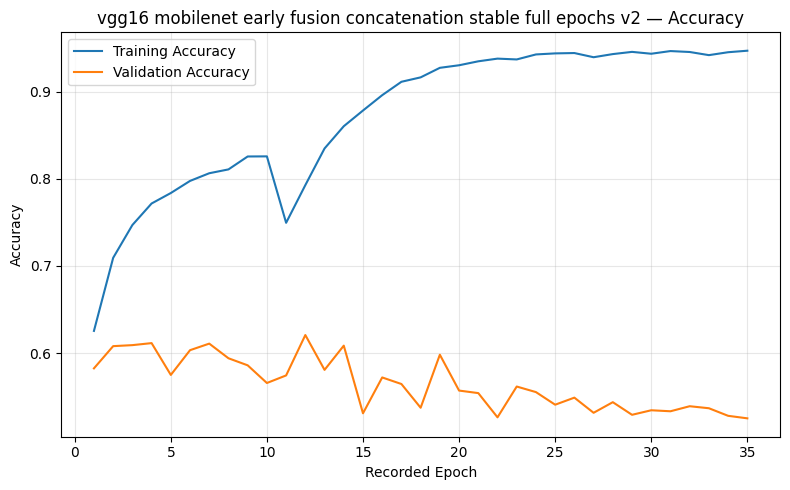

Saved: /content/drive/MyDrive/Patient_level_classification/Early_fusion_/VGG16_mobilenet_early_fusion_patient_level/VGG16_mobilenet_data_save_here/vgg16_mobilenet_early_fusion_concatenation_stable_full_epochs_v2_accuracy.png


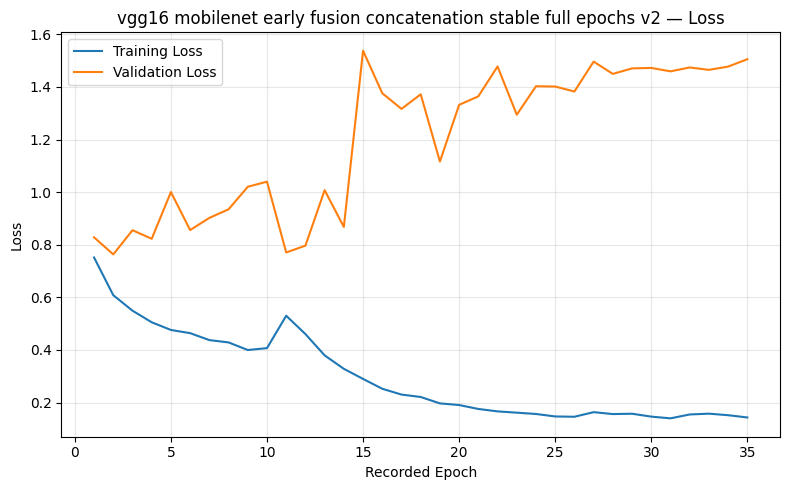

Saved: /content/drive/MyDrive/Patient_level_classification/Early_fusion_/VGG16_mobilenet_early_fusion_patient_level/VGG16_mobilenet_data_save_here/vgg16_mobilenet_early_fusion_concatenation_stable_full_epochs_v2_loss.png


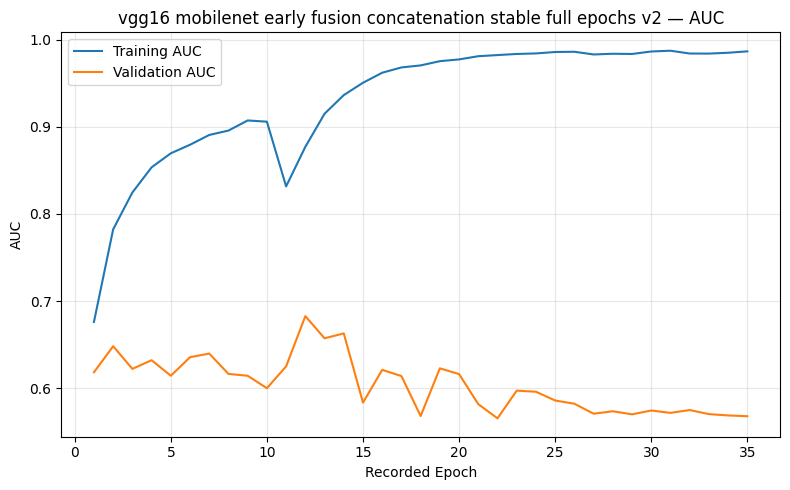

Saved: /content/drive/MyDrive/Patient_level_classification/Early_fusion_/VGG16_mobilenet_early_fusion_patient_level/VGG16_mobilenet_data_save_here/vgg16_mobilenet_early_fusion_concatenation_stable_full_epochs_v2_auc.png
240/240 ━━━━━━━━━━━━━━━━━━━━ 429s 2s/step
Saved and verified: /content/drive/MyDrive/Patient_level_classification/Early_fusion_/VGG16_mobilenet_early_fusion_patient_level/VGG16_mobilenet_data_save_here/vgg16_mobilenet_early_fusion_concatenation_stable_full_epochs_v2_slice_roc_data.npz
Saved and verified: /content/drive/MyDrive/Patient_level_classification/Early_fusion_/VGG16_mobilenet_early_fusion_patient_level/VGG16_mobilenet_data_save_here/vgg16_mobilenet_early_fusion_concatenation_stable_full_epochs_v2_patient_roc_data.npz


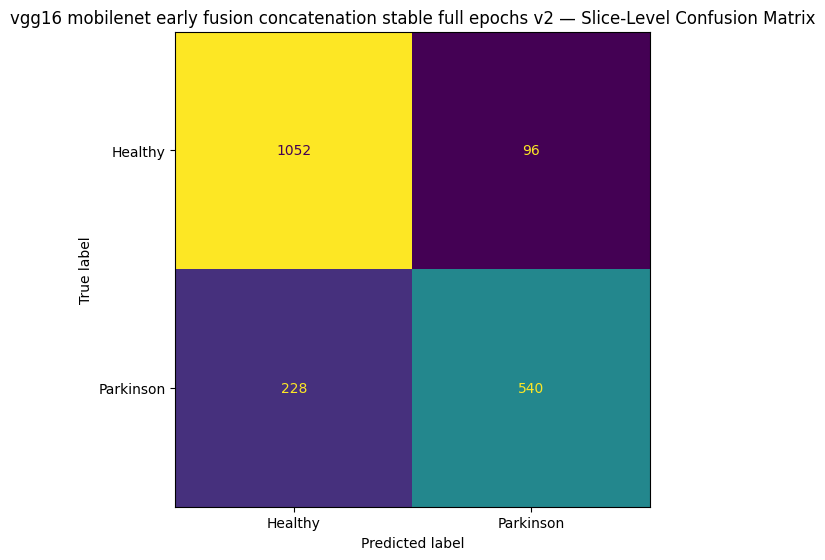

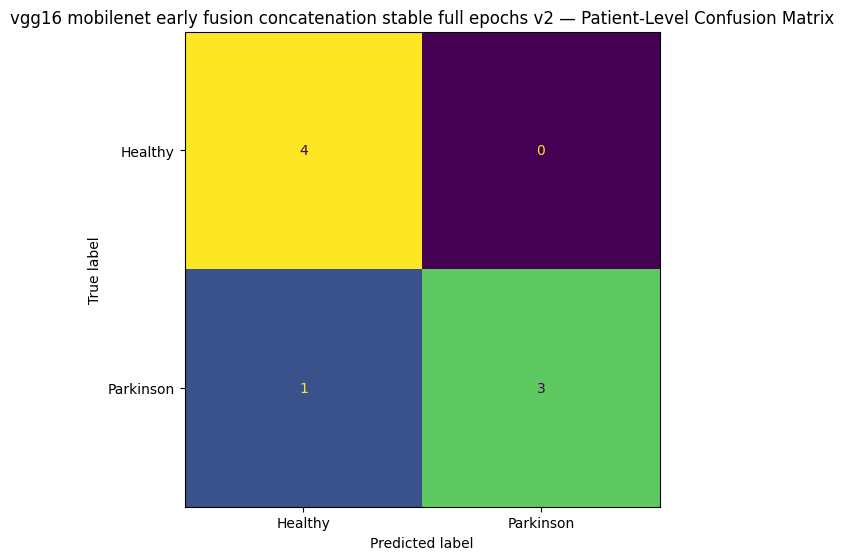

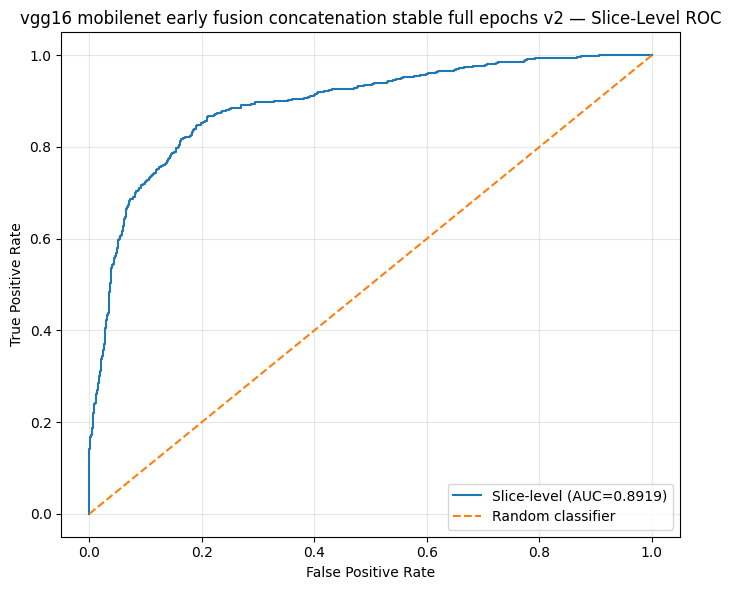

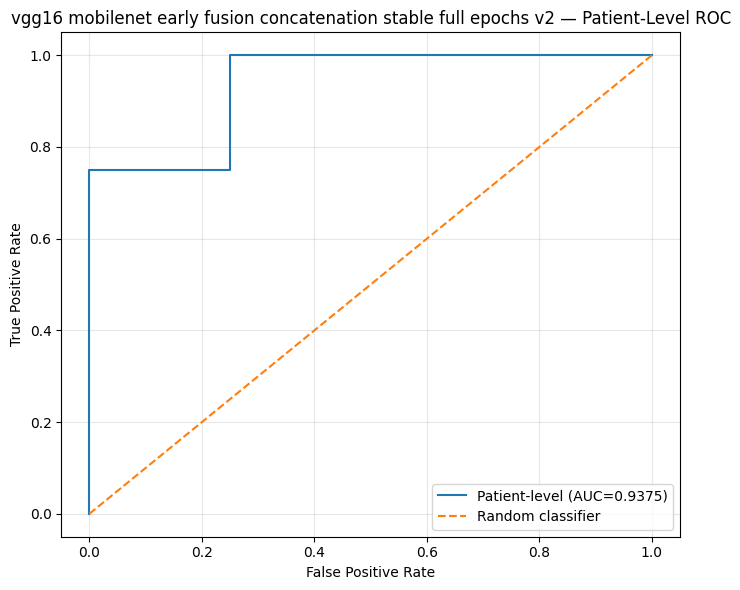


Evaluation complete: vgg16_mobilenet_early_fusion_concatenation_stable_full_epochs_v2
y_true shape: (1916,)
y_prob shape: (1916,)
Probability range: (2.0304680219851434e-05, 0.9996451139450073)
Slice metrics: {'accuracy': 0.8308977035490606, 'precision': 0.8490566037735849, 'recall': 0.703125, 'f1': 0.7692307692307693, 'auc': 0.891854493321719}
Patient metrics: {'accuracy': 0.875, 'precision': 1.0, 'recall': 0.75, 'f1': 0.8571428571428571, 'auc': 0.9375}


Model: "VGG16_MobileNetV2_Early_Fusion_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mri_input           │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_preprocessing │ (None, 224, 224,  │          0 │ mri_input[0][0]   │
│ (VGG16Preprocess)   │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_prepro… │ (None, 224, 224,  │          0 │ mri_input[0][0]   │
│ (MobileNetV2Prepro… │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_backbone      │ (None, 7, 7, 512) │ 14,714,688 │ vgg16_preprocess… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_backbo… │ (None, 7, 7,      │  2,257,984 │ mobilenetv2_prep… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_gap           │ (None, 512)       │          0 │ vgg16_backbone[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_gap     │ (None, 1280)      │          0 │ mobilenetv2_back… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_projected     │ (None, 256)       │    131,328 │ vgg16_gap[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_projec… │ (None, 256)       │    327,936 │ mobilenetv2_gap[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_input     │ (None, 512)       │          0 │ vgg16_projected[… │
│ (Concatenate)       │                   │            │ mobilenetv2_proj… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch_attention_w… │ (None, 2)         │      1,026 │ attention_input[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_attention_we… │ (None, 1)         │          0 │ branch_attention… │
│ (SelectAttentionWe… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_attent… │ (None, 1)         │          0 │ branch_attention… │
│ (SelectAttentionWe… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ weighted_vgg16_fea… │ (None, 256)       │          0 │ vgg16_projected[… │
│ (Multiply)          │                   │            │ vgg16_attention_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ weighted_mobilenet… │ (None, 256)       │          0 │ mobilenetv2_proj… │
│ (Multiply)          │                   │            │ mobilenetv2_atte… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ early_fusion_atten… │ (None, 256)       │          0 │ weighted_vgg16_f… │
│ (Add)               │                   │            │ weighted_mobilen… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_dense_256 │ (None, 256)       │     65,792 │ early_fusion_att

 Total params: 17,533,315 (66.88 MB)

 Trainable params: 559,875 (2.14 MB)

 Non-trainable params: 16,973,440 (64.75 MB)

                                   Model  Total Parameters  Trainable Parameters  Non-Trainable Parameters
VGG16_MobileNetV2_Early_Fusion_Attention          17533315                559875                  16973440
Saved: /content/drive/MyDrive/Patient_level_classification/Early_fusion_/VGG16_mobilenet_early_fusion_patient_level/VGG16_mobilenet_data_save_here/vgg16_mobilenet_early_fusion_attention_stable_full_epochs_v2_model_summary.txt
Saved: /content/drive/MyDrive/Patient_level_classification/Early_fusion_/VGG16_mobilenet_early_fusion_patient_level/VGG16_mobilenet_data_save_here/vgg16_mobilenet_early_fusion_attention_stable_full_epochs_v2_parameters.csv

Stage 1: frozen-backbone classifier training
Configured Stage 1 epochs: 10
Early stopping enabled: False
Epoch 1/10
935/935 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.5898 - auc: 0.6328 - loss: 0.8031 - precision: 0.6068 - recall: 0.5997
Epoch 1: val_auc improved from None to 0.64077, saving model to /content/drive/MyDrive/Patie

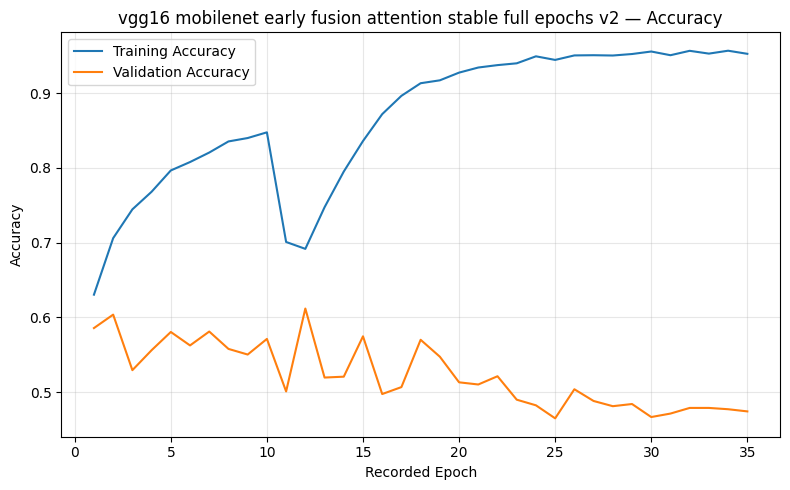

Saved: /content/drive/MyDrive/Patient_level_classification/Early_fusion_/VGG16_mobilenet_early_fusion_patient_level/VGG16_mobilenet_data_save_here/vgg16_mobilenet_early_fusion_attention_stable_full_epochs_v2_accuracy.png


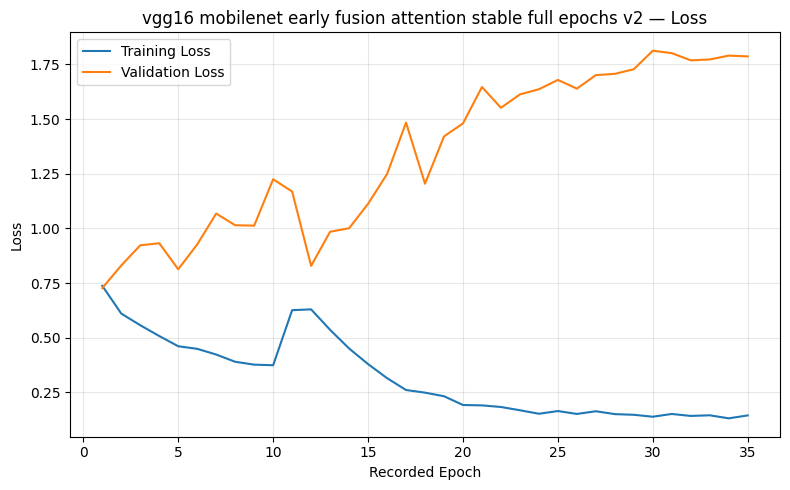

Saved: /content/drive/MyDrive/Patient_level_classification/Early_fusion_/VGG16_mobilenet_early_fusion_patient_level/VGG16_mobilenet_data_save_here/vgg16_mobilenet_early_fusion_attention_stable_full_epochs_v2_loss.png


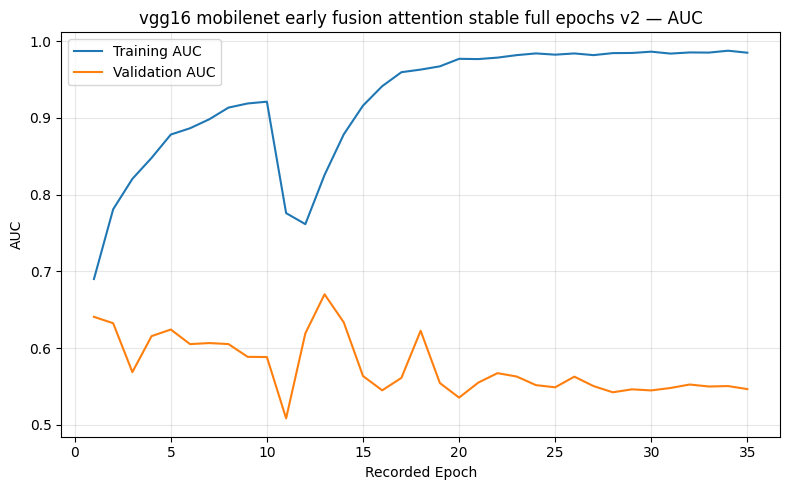

Saved: /content/drive/MyDrive/Patient_level_classification/Early_fusion_/VGG16_mobilenet_early_fusion_patient_level/VGG16_mobilenet_data_save_here/vgg16_mobilenet_early_fusion_attention_stable_full_epochs_v2_auc.png
240/240 ━━━━━━━━━━━━━━━━━━━━ 23s 75ms/step
Saved and verified: /content/drive/MyDrive/Patient_level_classification/Early_fusion_/VGG16_mobilenet_early_fusion_patient_level/VGG16_mobilenet_data_save_here/vgg16_mobilenet_early_fusion_attention_stable_full_epochs_v2_slice_roc_data.npz
Saved and verified: /content/drive/MyDrive/Patient_level_classification/Early_fusion_/VGG16_mobilenet_early_fusion_patient_level/VGG16_mobilenet_data_save_here/vgg16_mobilenet_early_fusion_attention_stable_full_epochs_v2_patient_roc_data.npz


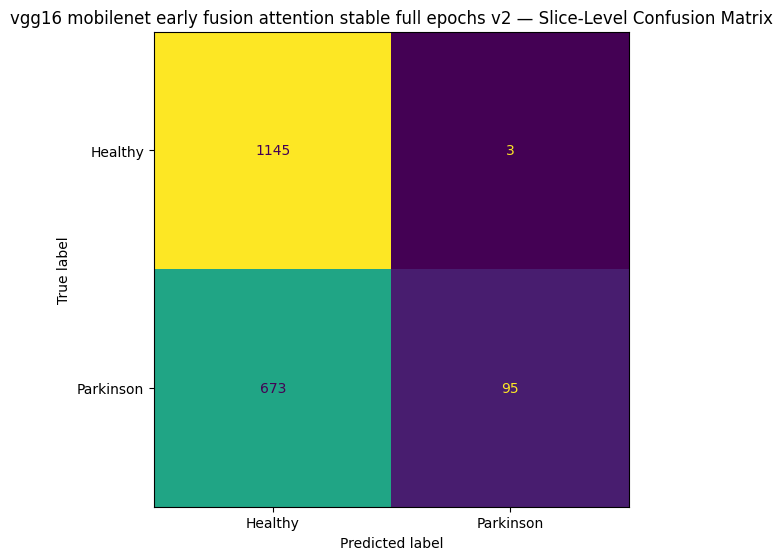

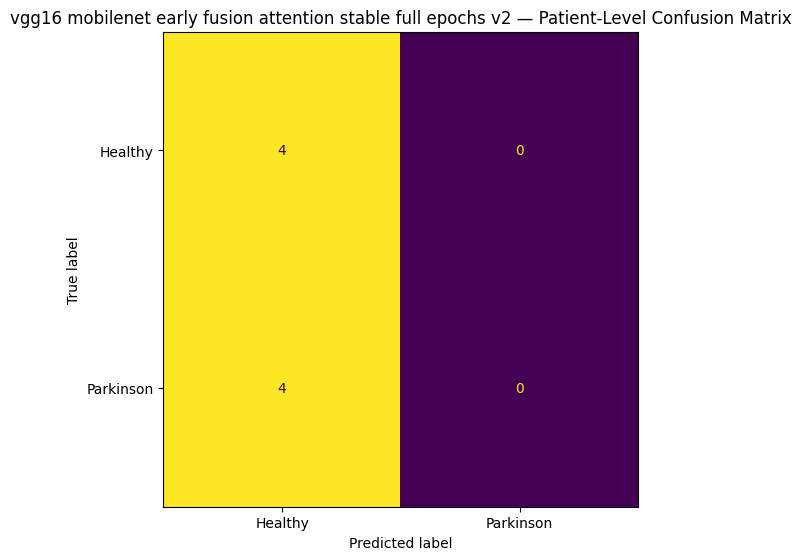

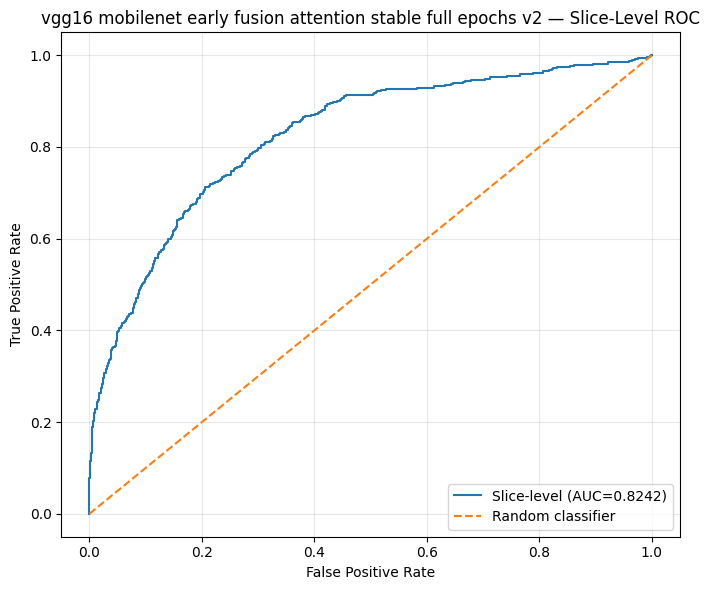

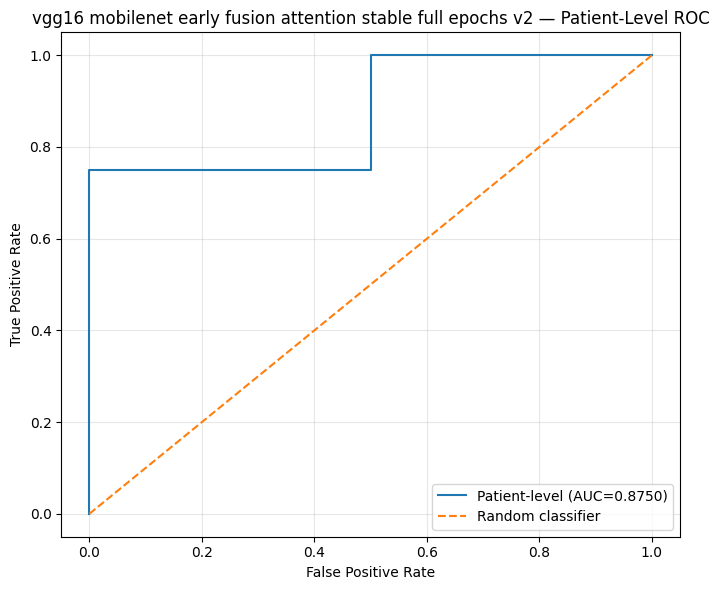


Evaluation complete: vgg16_mobilenet_early_fusion_attention_stable_full_epochs_v2
y_true shape: (1916,)
y_prob shape: (1916,)
Probability range: (0.0002181391027988866, 0.8571311831474304)
Slice metrics: {'accuracy': 0.6471816283924844, 'precision': 0.9693877551020408, 'recall': 0.12369791666666667, 'f1': 0.21939953810623555, 'auc': 0.824240300159698}
Patient metrics: {'accuracy': 0.5, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'auc': 0.875}

Completed model experiments:
['vgg16_mobilenet_early_fusion_concatenation_stable_full_epochs_v2', 'vgg16_mobilenet_early_fusion_attention_stable_full_epochs_v2']


In [18]:
# ============================================================
# 20. TRAIN AND EVALUATE BOTH EARLY-FUSION MODELS
# ============================================================
def plot_history_metric(
    history,
    metric,
    display_name,
    prefix
):
    train_values = history.get(metric, [])
    validation_values = history.get(
        f"val_{metric}",
        []
    )

    if not train_values or not validation_values:
        print(
            f"Skipping {metric} plot; history unavailable."
        )
        return

    epochs = np.arange(
        1,
        len(train_values) + 1
    )

    figure, axis = plt.subplots(
        figsize=(8, 5)
    )

    axis.plot(
        epochs,
        train_values,
        label=f"Training {display_name}"
    )

    axis.plot(
        epochs,
        validation_values,
        label=f"Validation {display_name}"
    )

    axis.set_xlabel("Recorded Epoch")
    axis.set_ylabel(display_name)
    axis.set_title(
        f"{prefix.replace('_', ' ')} — {display_name}"
    )
    axis.grid(alpha=0.3)
    axis.legend()
    figure.tight_layout()

    save_path = (
        ROOT_OUTPUT_DIR
        / f"{prefix}_{metric}.png"
    )

    figure.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(figure)

    print("Saved:", save_path)


def run_model_experiment(
    prefix,
    builder_function
):
    final_model_path = (
        ROOT_OUTPUT_DIR
        / f"{prefix}_best.keras"
    )

    if (
        REUSE_COMPLETED_MODELS
        and final_model_path.exists()
    ):
        print(
            "\nLoading completed model:",
            final_model_path
        )
        model = load_fusion_model(
            final_model_path
        )
        history = load_json(
            ROOT_OUTPUT_DIR
            / f"{prefix}_history.json",
            default={}
        )
        training_summary = load_json(
            ROOT_OUTPUT_DIR
            / f"{prefix}_training_summary.json",
            default={}
        )
    else:
        tf.keras.backend.clear_session()
        gc.collect()

        model = builder_function(
            base_trainable=False
        )

        # Test one forward pass before long training.
        dummy_output = model(
            tf.zeros(
                (1, IMG_SIZE, IMG_SIZE, 3),
                dtype=tf.float32
            ),
            training=False
        )

        if (
            dummy_output.shape != (1, 1)
            or not np.all(
                np.isfinite(
                    dummy_output.numpy()
                )
            )
        ):
            raise RuntimeError(
                "Model forward-pass validation failed."
            )

        model.summary()
        save_model_information(
            model,
            prefix
        )

        (
            model,
            history,
            training_summary
        ) = train_two_stage_model(
            model,
            prefix
        )

    for metric, name in [
        ("accuracy", "Accuracy"),
        ("loss", "Loss"),
        ("auc", "AUC")
    ]:
        plot_history_metric(
            history,
            metric,
            name,
            prefix
        )

    result = evaluate_fusion_model(
        model,
        prefix
    )

    result["training_summary"] = (
        training_summary
    )

    return result


all_model_results = {}
trained_model_paths = {}

if RUN_CONCATENATION_MODEL:
    concat_results = run_model_experiment(
        CONCAT_PREFIX,
        build_concat_model
    )

    all_model_results[
        CONCAT_PREFIX
    ] = concat_results

    trained_model_paths[
        CONCAT_PREFIX
    ] = concat_results["model_path"]

    gc.collect()

if RUN_ATTENTION_MODEL:
    attention_results = run_model_experiment(
        ATTENTION_PREFIX,
        build_attention_model
    )

    all_model_results[
        ATTENTION_PREFIX
    ] = attention_results

    trained_model_paths[
        ATTENTION_PREFIX
    ] = attention_results["model_path"]

    gc.collect()

if not all_model_results:
    raise RuntimeError(
        "No model ran. Enable at least one model."
    )

print("\nCompleted model experiments:")
print(list(all_model_results.keys()))

In [19]:
# ============================================================
# 21. COMPARE MODELS AND CREATE STANDARD ROC NPZ ALIASES
# ============================================================
if not all_model_results:
    raise RuntimeError(
        "No completed model results are available."
    )

comparison_df = pd.DataFrame([
    result["metrics"]
    for result in all_model_results.values()
])

comparison_path = (
    ROOT_OUTPUT_DIR
    / "vgg16_mobilenet_early_fusion_model_comparison.csv"
)

comparison_df.to_csv(
    comparison_path,
    index=False
)

display(comparison_df)

ranking_columns = [
    "Patient ROC AUC",
    "Patient F1",
    "Patient Accuracy"
]

ranked_df = comparison_df.sort_values(
    by=ranking_columns,
    ascending=False,
    na_position="last"
).reset_index(drop=True)

best_prefix = str(
    ranked_df.loc[0, "Model Prefix"]
)

best_result = all_model_results[
    best_prefix
]

best_model_path = Path(
    best_result["model_path"]
)

if not best_model_path.exists():
    raise FileNotFoundError(
        f"Best model missing: {best_model_path}"
    )

with np.load(
    best_result["slice_npz_path"]
) as slice_data:
    standard_slice_npz = (
        ROOT_OUTPUT_DIR
        / "vgg16_mobilenet_early_fusion_roc_data.npz"
    )

    np.savez_compressed(
        standard_slice_npz,
        y_true=slice_data["y_true"],
        y_prob=slice_data["y_prob"]
    )

with np.load(
    best_result["patient_npz_path"]
) as patient_data:
    standard_patient_npz = (
        ROOT_OUTPUT_DIR
        / (
            "vgg16_mobilenet_early_fusion_"
            "patient_roc_data.npz"
        )
    )

    np.savez_compressed(
        standard_patient_npz,
        y_true=patient_data["y_true"],
        y_prob=patient_data["y_prob"]
    )

best_summary = {
    "best_prefix": best_prefix,
    "best_model_path": str(
        best_model_path
    ),
    "ranking_columns": ranking_columns,
    "metrics": best_result["metrics"],
    "standard_slice_roc_npz": str(
        standard_slice_npz
    ),
    "standard_patient_roc_npz": str(
        standard_patient_npz
    )
}

save_json(
    best_summary,
    ROOT_OUTPUT_DIR
    / "vgg16_mobilenet_best_early_fusion_summary.json"
)

print("Best early-fusion model:", best_prefix)
print("Best model path:", best_model_path)
print("Standard slice ROC NPZ:", standard_slice_npz)
print("Standard patient ROC NPZ:", standard_patient_npz)

,Model Prefix,Slice Accuracy,Slice Precision,Slice Recall,Slice F1,Slice ROC AUC,Patient Accuracy,Patient Precision,Patient Recall,Patient F1,Patient ROC AUC,Test Slices,Test Patients
0,vgg16_mobilenet_early_fusion_concatenation_sta...,0.830898,0.849057,0.703125,0.769231,0.891854,0.875,1.0,0.75,0.857143,0.9375,1916,8
1,vgg16_mobilenet_early_fusion_attention_stable_...,0.647182,0.969388,0.123698,0.219400,0.824240,0.500,0.0,0.00,0.000000,0.8750,1916,8


Best early-fusion model: vgg16_mobilenet_early_fusion_concatenation_stable_full_epochs_v2
Best model path: /content/drive/MyDrive/Patient_level_classification/Early_fusion_/VGG16_mobilenet_early_fusion_patient_level/VGG16_mobilenet_data_save_here/vgg16_mobilenet_early_fusion_concatenation_stable_full_epochs_v2_best.keras
Standard slice ROC NPZ: /content/drive/MyDrive/Patient_level_classification/Early_fusion_/VGG16_mobilenet_early_fusion_patient_level/VGG16_mobilenet_data_save_here/vgg16_mobilenet_early_fusion_roc_data.npz
Standard patient ROC NPZ: /content/drive/MyDrive/Patient_level_classification/Early_fusion_/VGG16_mobilenet_early_fusion_patient_level/VGG16_mobilenet_data_save_here/vgg16_mobilenet_early_fusion_patient_roc_data.npz



## Branch-wise Grad-CAM for the best model

The final prediction comes from the complete early-fusion model. The two heatmaps are calculated separately from the VGG16 and MobileNetV2 convolutional branches.


In [20]:
# ============================================================
# 23. LOAD THE BEST MODEL FOR GRAD-CAM
# ============================================================
best_model = load_fusion_model(
    best_model_path
)

print("Loaded best model:", best_model.name)
print("Inputs:", best_model.inputs)
print("Output:", best_model.output)

find_fusion_backbones(
    best_model
)

print("Best-model loading check: PASSED")

Loaded best model: VGG16_MobileNetV2_Early_Fusion_Concatenation
Inputs: [<KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, ragged=False, name=mri_input>]
Output: <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=keras_tensor_593>
Detected VGG16 backbone: vgg16_backbone
Detected MobileNetV2 backbone: mobilenetv2_backbone
Best-model loading check: PASSED


In [21]:

# ============================================================
# 20. KERAS 3–SAFE BRANCH GRAD-CAM
# ============================================================
VGG_LAYER_CANDIDATES = [
    "block5_conv3",
    "block5_conv2",
    "block5_conv1",
    "block4_conv3"
]

MOBILE_LAYER_CANDIDATES = [
    "Conv_1",
    "block_16_project",
    "block_15_project",
    "block_14_project"
]


def get_existing_layer_name(backbone, candidates):
    existing = {
        layer.name
        for layer in backbone.layers
    }

    for candidate in candidates:
        if candidate in existing:
            layer = backbone.get_layer(candidate)

            if len(layer.output.shape) == 4:
                return candidate

    conv_layers = [
        layer
        for layer in backbone.layers
        if isinstance(layer, layers.Conv2D)
        and len(layer.output.shape) == 4
    ]

    if not conv_layers:
        raise ValueError(
            f"No valid Conv2D layer found in {backbone.name}."
        )

    return conv_layers[-1].name


def forward_fusion_head(
    model,
    vgg_backbone_output,
    mobile_backbone_output
):
    vgg_vector = model.get_layer(
        "vgg16_gap"
    )(vgg_backbone_output)

    mobile_vector = model.get_layer(
        "mobilenetv2_gap"
    )(mobile_backbone_output)

    if "early_fusion_concatenation" in [
        layer.name for layer in model.layers
    ]:
        x = model.get_layer(
            "early_fusion_concatenation"
        )([vgg_vector, mobile_vector])

        for layer_name in [
            "concat_dense_512",
            "concat_bn_512",
            "concat_dropout_512",
            "concat_dense_256",
            "concat_bn_256",
            "concat_dropout_256",
            "concat_dense_128",
            "concat_bn_128",
            "concat_dropout_128",
            "prediction"
        ]:
            layer = model.get_layer(layer_name)

            try:
                x = layer(x, training=False)
            except TypeError:
                x = layer(x)

        return x

    vgg_projected = model.get_layer(
        "vgg16_projected"
    )(vgg_vector)

    mobile_projected = model.get_layer(
        "mobilenetv2_projected"
    )(mobile_vector)

    attention_input = model.get_layer(
        "attention_input"
    )([vgg_projected, mobile_projected])

    attention_weights = model.get_layer(
        "branch_attention_weights"
    )(attention_input)

    vgg_weight = model.get_layer(
        "vgg16_attention_weight"
    )(attention_weights)

    mobile_weight = model.get_layer(
        "mobilenetv2_attention_weight"
    )(attention_weights)

    weighted_vgg = model.get_layer(
        "weighted_vgg16_features"
    )([vgg_projected, vgg_weight])

    weighted_mobile = model.get_layer(
        "weighted_mobilenetv2_features"
    )([mobile_projected, mobile_weight])

    x = model.get_layer(
        "early_fusion_attention"
    )([weighted_vgg, weighted_mobile])

    for layer_name in [
        "attention_dense_256",
        "attention_bn_256",
        "attention_dropout_256",
        "attention_dense_128",
        "attention_bn_128",
        "attention_dropout_128",
        "prediction"
    ]:
        layer = model.get_layer(layer_name)

        try:
            x = layer(x, training=False)
        except TypeError:
            x = layer(x)

    return x


def normalize_gradcam(feature_maps, gradients):
    if gradients is None:
        raise RuntimeError("Gradients are None.")

    gradient_norm = float(tf.norm(gradients))

    if gradient_norm <= 1e-12:
        raise RuntimeError(
            "Gradient norm is effectively zero."
        )

    pooled_gradients = tf.reduce_mean(
        gradients,
        axis=(0, 1, 2)
    )

    raw_heatmap = tf.reduce_sum(
        feature_maps[0] * pooled_gradients,
        axis=-1
    )

    raw_heatmap = tf.maximum(
        raw_heatmap,
        0
    )

    raw_maximum = float(
        tf.reduce_max(raw_heatmap)
    )

    if raw_maximum <= 1e-12:
        raise RuntimeError(
            "Raw Grad-CAM heatmap is zero."
        )

    normalized = (
        raw_heatmap / raw_maximum
    ).numpy()

    return normalized, gradient_norm


def calculate_branch_gradcams(
    model,
    image_batch,
    target_class
):
    vgg_backbone, mobile_backbone = find_fusion_backbones(model)

    vgg_candidates = [
        name for name in VGG_LAYER_CANDIDATES
        if name in {
            layer.name
            for layer in vgg_backbone.layers
        }
    ]

    mobile_candidates = [
        name for name in MOBILE_LAYER_CANDIDATES
        if name in {
            layer.name
            for layer in mobile_backbone.layers
        }
    ]

    if not vgg_candidates:
        vgg_candidates = [
            get_existing_layer_name(
                vgg_backbone,
                VGG_LAYER_CANDIDATES
            )
        ]

    if not mobile_candidates:
        mobile_candidates = [
            get_existing_layer_name(
                mobile_backbone,
                MOBILE_LAYER_CANDIDATES
            )
        ]

    last_error = None

    for vgg_layer_name in vgg_candidates:
        for mobile_layer_name in mobile_candidates:
            try:
                vgg_extractor = keras.Model(
                    inputs=vgg_backbone.input,
                    outputs=[
                        vgg_backbone.get_layer(
                            vgg_layer_name
                        ).output,
                        vgg_backbone.output
                    ]
                )

                mobile_extractor = keras.Model(
                    inputs=mobile_backbone.input,
                    outputs=[
                        mobile_backbone.get_layer(
                            mobile_layer_name
                        ).output,
                        mobile_backbone.output
                    ]
                )

                image_tensor = tf.convert_to_tensor(
                    image_batch,
                    dtype=tf.float32
                )

                with tf.GradientTape(
                    persistent=True
                ) as tape:
                    vgg_input = model.get_layer(
                        "vgg16_preprocessing"
                    )(image_tensor)

                    mobile_input = model.get_layer(
                        "mobilenetv2_preprocessing"
                    )(image_tensor)

                    (
                        vgg_feature_maps,
                        vgg_backbone_output
                    ) = vgg_extractor(
                        vgg_input,
                        training=False
                    )

                    (
                        mobile_feature_maps,
                        mobile_backbone_output
                    ) = mobile_extractor(
                        mobile_input,
                        training=False
                    )

                    prediction = forward_fusion_head(
                        model,
                        vgg_backbone_output,
                        mobile_backbone_output
                    )

                    probability = tf.clip_by_value(
                        prediction[:, 0],
                        1e-7,
                        1.0 - 1e-7
                    )

                    logit = tf.math.log(
                        probability
                        / (1.0 - probability)
                    )

                    target_score = tf.reduce_sum(
                        logit
                        if int(target_class) == 1
                        else -logit
                    )

                vgg_gradients = tape.gradient(
                    target_score,
                    vgg_feature_maps
                )

                mobile_gradients = tape.gradient(
                    target_score,
                    mobile_feature_maps
                )

                del tape

                (
                    vgg_heatmap,
                    vgg_gradient_norm
                ) = normalize_gradcam(
                    vgg_feature_maps,
                    vgg_gradients
                )

                (
                    mobile_heatmap,
                    mobile_gradient_norm
                ) = normalize_gradcam(
                    mobile_feature_maps,
                    mobile_gradients
                )

                return {
                    "vgg_heatmap": vgg_heatmap,
                    "mobile_heatmap": mobile_heatmap,
                    "probability": float(
                        probability[0]
                    ),
                    "target_score": float(
                        target_score
                    ),
                    "vgg_layer": vgg_layer_name,
                    "mobile_layer": mobile_layer_name,
                    "vgg_gradient_norm": (
                        vgg_gradient_norm
                    ),
                    "mobile_gradient_norm": (
                        mobile_gradient_norm
                    )
                }

            except Exception as error:
                last_error = error
                print(
                    "Grad-CAM attempt failed:",
                    vgg_layer_name,
                    mobile_layer_name,
                    repr(error)
                )

    raise RuntimeError(
        "All branch Grad-CAM layer combinations failed. "
        f"Last error: {last_error}"
    )


Using existing best model information.
Detected VGG16 backbone: vgg16_backbone
Detected MobileNetV2 backbone: mobilenetv2_backbone


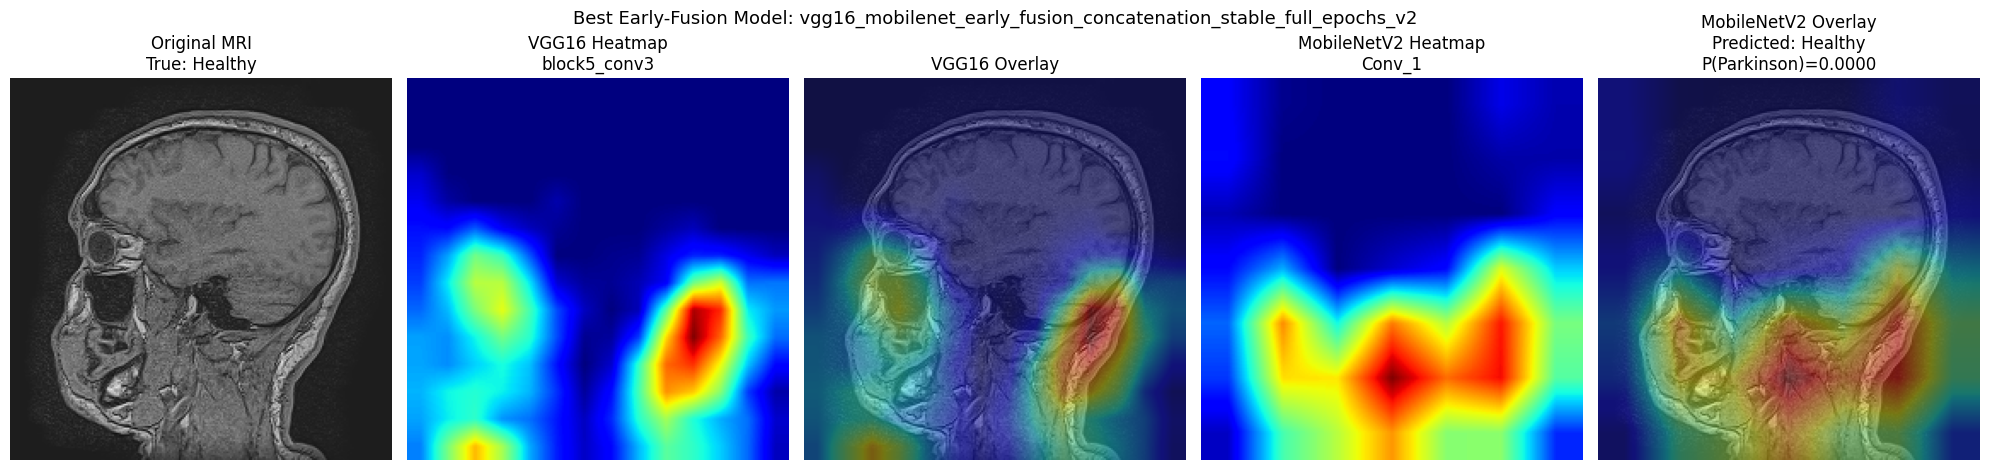

Saved: /content/drive/MyDrive/Patient_level_classification/Early_fusion_/VGG16_mobilenet_early_fusion_patient_level/VGG16_mobilenet_data_save_here/vgg16_mobilenet_early_fusion_gradcam_healthy_1.png
Saved: /content/drive/MyDrive/Patient_level_classification/Early_fusion_/VGG16_mobilenet_early_fusion_patient_level/VGG16_mobilenet_data_save_here/vgg16_mobilenet_early_fusion_gradcam_healthy_1.npz
Detected VGG16 backbone: vgg16_backbone
Detected MobileNetV2 backbone: mobilenetv2_backbone


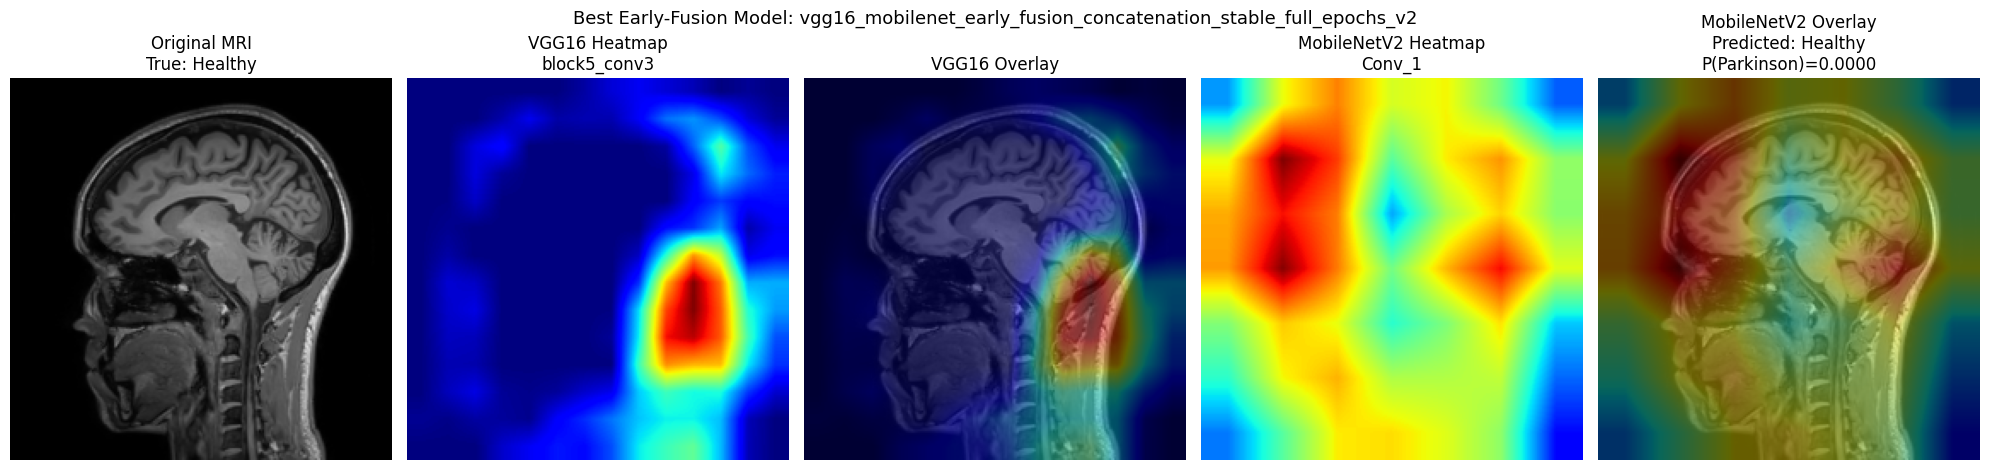

Saved: /content/drive/MyDrive/Patient_level_classification/Early_fusion_/VGG16_mobilenet_early_fusion_patient_level/VGG16_mobilenet_data_save_here/vgg16_mobilenet_early_fusion_gradcam_healthy_2.png
Saved: /content/drive/MyDrive/Patient_level_classification/Early_fusion_/VGG16_mobilenet_early_fusion_patient_level/VGG16_mobilenet_data_save_here/vgg16_mobilenet_early_fusion_gradcam_healthy_2.npz
Detected VGG16 backbone: vgg16_backbone
Detected MobileNetV2 backbone: mobilenetv2_backbone


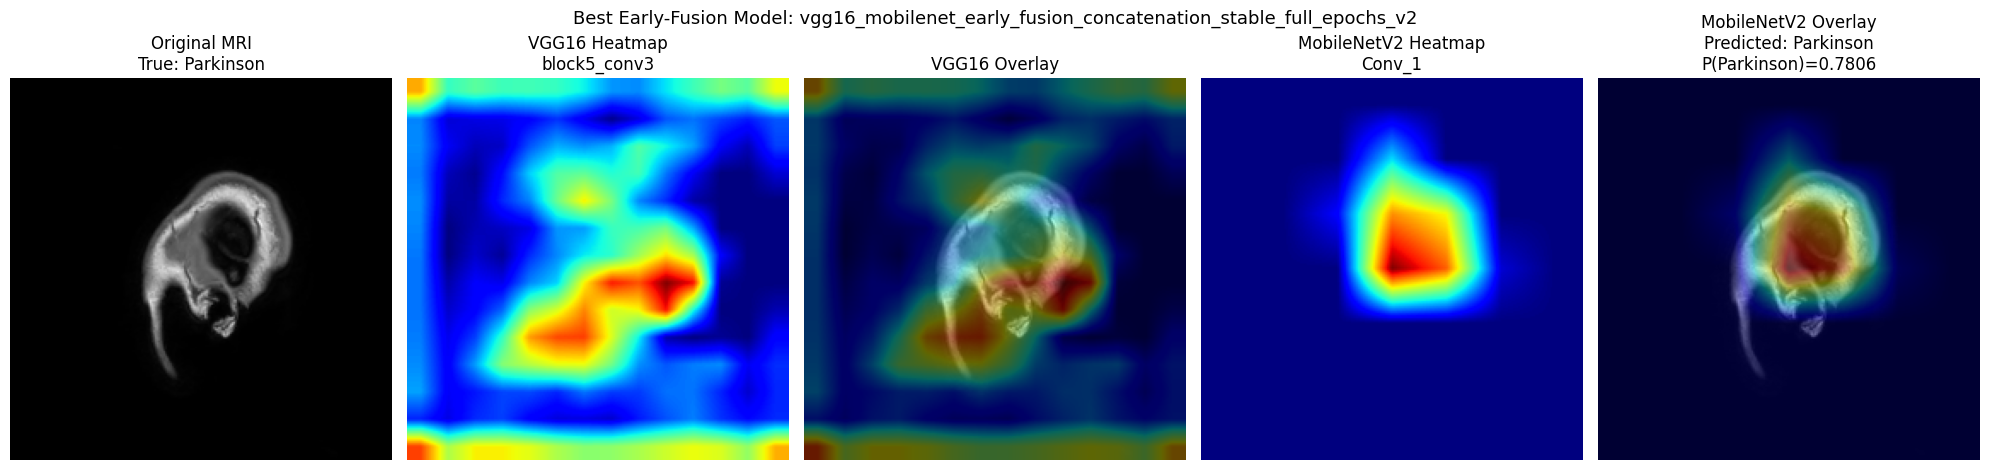

Saved: /content/drive/MyDrive/Patient_level_classification/Early_fusion_/VGG16_mobilenet_early_fusion_patient_level/VGG16_mobilenet_data_save_here/vgg16_mobilenet_early_fusion_gradcam_parkinson_1.png
Saved: /content/drive/MyDrive/Patient_level_classification/Early_fusion_/VGG16_mobilenet_early_fusion_patient_level/VGG16_mobilenet_data_save_here/vgg16_mobilenet_early_fusion_gradcam_parkinson_1.npz
Detected VGG16 backbone: vgg16_backbone
Detected MobileNetV2 backbone: mobilenetv2_backbone


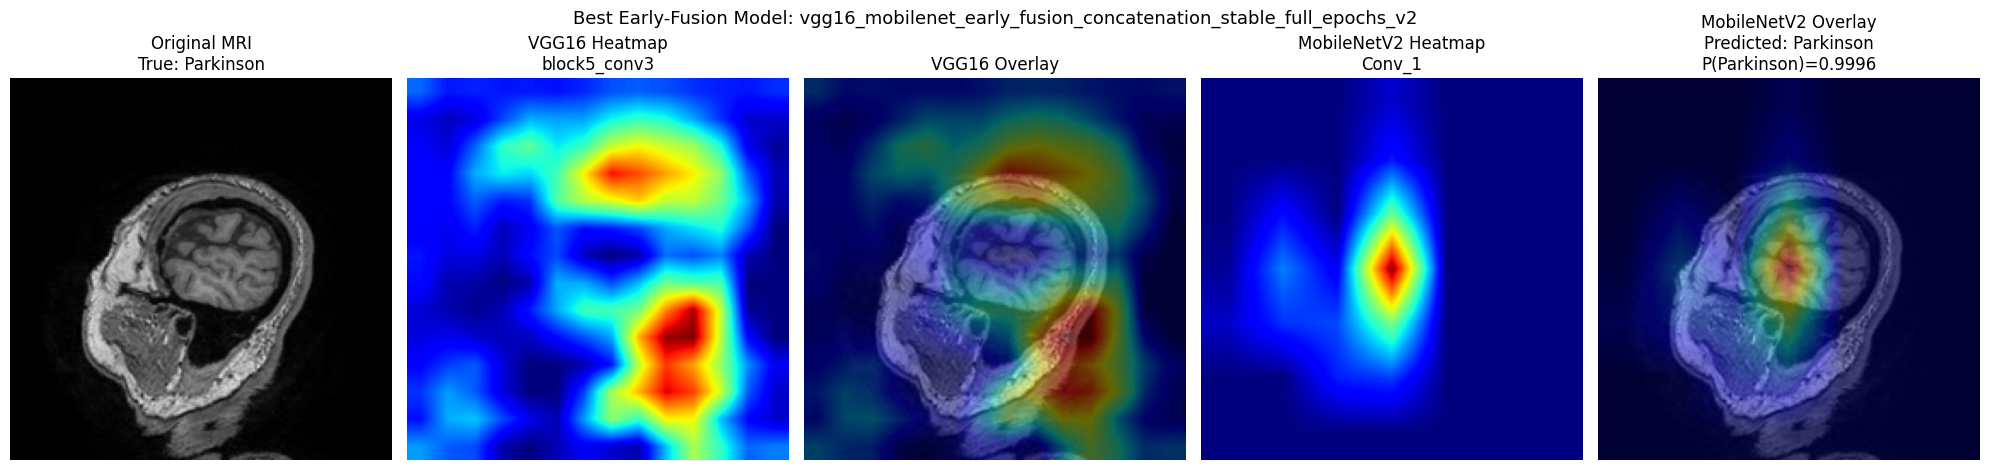

Saved: /content/drive/MyDrive/Patient_level_classification/Early_fusion_/VGG16_mobilenet_early_fusion_patient_level/VGG16_mobilenet_data_save_here/vgg16_mobilenet_early_fusion_gradcam_parkinson_2.png
Saved: /content/drive/MyDrive/Patient_level_classification/Early_fusion_/VGG16_mobilenet_early_fusion_patient_level/VGG16_mobilenet_data_save_here/vgg16_mobilenet_early_fusion_gradcam_parkinson_2.npz


,figure_path,npz_path,true_class,predicted_class,parkinson_probability,patient_id,image_path,vgg16_layer,mobilenetv2_layer,vgg16_gradient_norm,mobilenetv2_gradient_norm
0,/content/drive/MyDrive/Patient_level_classific...,/content/drive/MyDrive/Patient_level_classific...,Healthy,Healthy,0.000020,162905,/content/drive/MyDrive/Patient_level_classific...,block5_conv3,Conv_1,0.122173,0.336804
1,/content/drive/MyDrive/Patient_level_classific...,/content/drive/MyDrive/Patient_level_classific...,Healthy,Healthy,0.000023,130190,/content/drive/MyDrive/Patient_level_classific...,block5_conv3,Conv_1,0.161590,0.490224
2,/content/drive/MyDrive/Patient_level_classific...,/content/drive/MyDrive/Patient_level_classific...,Parkinson,Parkinson,0.780641,101179,/content/drive/MyDrive/Patient_level_classific...,block5_conv3,Conv_1,0.081269,0.269452
3,/content/drive/MyDrive/Patient_level_classific...,/content/drive/MyDrive/Patient_level_classific...,Parkinson,Parkinson,0.999646,101799,/content/drive/MyDrive/Patient_level_classific...,block5_conv3,Conv_1,0.096457,0.290831


Saved: /content/drive/MyDrive/Patient_level_classification/Early_fusion_/VGG16_mobilenet_early_fusion_patient_level/VGG16_mobilenet_data_save_here/vgg16_mobilenet_early_fusion_gradcam_summary.csv


In [22]:
import cv2

# ============================================================
# 21. GRAD-CAM DISPLAY AND SAMPLE SELECTION
# ============================================================
def load_display_image(image_path):
    image = keras.utils.load_img(
        image_path,
        target_size=(IMG_SIZE, IMG_SIZE),
        color_mode="rgb"
    )

    array = keras.utils.img_to_array(
        image
    ).astype(np.float32)

    return array


def resize_and_color_heatmap(
    heatmap,
    target_shape
):
    resized = tf.image.resize(
        heatmap[..., np.newaxis],
        target_shape[:2],
        method="bilinear"
    ).numpy().squeeze()

    resized = np.clip(
        resized,
        0.0,
        1.0
    )

    # Matplotlib returns RGBA. Keep only RGB.
    colored = plt.colormaps["jet"](
        resized
    )[..., :3].astype(np.float32)

    return resized, colored


def make_overlay(
    original_image,
    colored_heatmap,
    alpha=0.40
):
    original = original_image.astype(np.float32)

    if original.max() > 1.0:
        original = original / 255.0

    if original.shape != colored_heatmap.shape:
        raise ValueError(
            f"RGB shape mismatch: "
            f"{original.shape} and "
            f"{colored_heatmap.shape}"
        )

    return np.clip(
        (1.0 - alpha) * original
        + alpha * colored_heatmap,
        0.0,
        1.0
    )

# If best_result or best_prefix are not globally defined, attempt to re-derive them
# from saved CSV files. This handles kernel resets or out-of-order execution.
if 'best_prefix' not in globals() or 'best_result' not in globals():
    print("Attempting to re-derive best model information for Grad-CAM display...")
    comparison_path = (
        ROOT_OUTPUT_DIR
        / "vgg16_mobilenet_early_fusion_model_comparison.csv"
    )
    if not comparison_path.exists():
        print(f"WARNING: Comparison CSV not found at {comparison_path}. "
              "Please ensure cell 9fd0e775 and b7a7aebc were executed successfully.")
        raise FileNotFoundError(f"Required comparison CSV not found: {comparison_path}")

    comparison_df = pd.read_csv(comparison_path)
    ranked_df = comparison_df.sort_values(
        by=[
            "Patient ROC AUC",
            "Patient F1",
            "Patient Accuracy"
        ],
        ascending=False
    ).reset_index(drop=True)
    best_prefix = ranked_df.loc[0, "Model Prefix"]

    best_slice_predictions_path = (
        ROOT_OUTPUT_DIR
        / f"{best_prefix}_slice_predictions.csv"
    )
    if not best_slice_predictions_path.exists():
        print(f"WARNING: Slice predictions CSV for best model not found at {best_slice_predictions_path}. "
              "Please ensure cell 9fd0e775 and b7a7aebc were executed successfully.")
        raise FileNotFoundError(f"Required slice predictions CSV not found: {best_slice_predictions_path}")

    # Load the best prediction dataframe directly
    best_prediction_df_loaded = pd.read_csv(best_slice_predictions_path)

    # Create a minimal best_result dictionary containing just the necessary slice_predictions
    best_result = {"slice_predictions": best_prediction_df_loaded}
    print(f"Best model prefix re-derived: {best_prefix}")
    print(f"Loaded slice predictions from: {best_slice_predictions_path}")
else:
    # If best_result and best_prefix are already defined globally, use them.
    print("Using existing best model information.")

best_prediction_df = (
    best_result["slice_predictions"]
    .copy()
)

correct_candidates = best_prediction_df[
    best_prediction_df["correct"] == True
].copy()

# All images were used in training. For display only, prefer slices
# near each patient's median slice index and confident predictions.

saved_gradcam_records = []

for target_label, class_name in [
    (0, "Healthy"),
    (1, "Parkinson")
]:
    class_candidates = correct_candidates[
        correct_candidates["label"]
        == target_label
    ].copy()

    # Prefer distinct patients.
    class_candidates["display_confidence"] = np.where(
        class_candidates["label"] == 1,
        class_candidates["predicted_probability"],
        1.0 - class_candidates["predicted_probability"]
    )

    if class_candidates["slice_index"].notna().any():
        patient_medians = class_candidates.groupby(
            "patient_id"
        )["slice_index"].transform("median")
        class_candidates["central_distance"] = (
            class_candidates["slice_index"] - patient_medians
        ).abs().fillna(np.inf)
    else:
        class_candidates["central_distance"] = np.inf

    class_candidates = class_candidates.sort_values(
        ["central_distance", "display_confidence"],
        ascending=[True, False]
    ).drop_duplicates("patient_id")

    saved_count = 0

    for _, row in class_candidates.head(30).iterrows():
        if saved_count >= 2:
            break

        try:
            display_image = load_display_image(
                row["image_path"]
            )

            image_batch = np.expand_dims(
                display_image,
                axis=0
            ).astype(np.float32)

            # best_model is expected to be loaded in cell beb2c198
            gradcam_result = calculate_branch_gradcams(
                best_model,
                image_batch,
                target_class=target_label
            )

            (
                vgg_resized,
                vgg_colored
            ) = resize_and_color_heatmap(
                gradcam_result["vgg_heatmap"],
                display_image.shape
            )

            (
                mobile_resized,
                mobile_colored
            ) = resize_and_color_heatmap(
                gradcam_result["mobile_heatmap"],
                display_image.shape
            )

            vgg_overlay = make_overlay(
                display_image,
                vgg_colored
            )

            mobile_overlay = make_overlay(
                display_image,
                mobile_colored
            )

            predicted_class = (
                "Parkinson"
                if gradcam_result["probability"] >= 0.5
                else "Healthy"
            )

            figure, axes = plt.subplots(
                1,
                5,
                figsize=(20, 5)
            )

            axes[0].imshow(
                display_image.astype(np.uint8)
            )
            axes[0].set_title(
                f"Original MRI\nTrue: {class_name}"
            )
            axes[0].axis("off")

            axes[1].imshow(
                vgg_resized,
                cmap="jet",
                vmin=0,
                vmax=1
            )
            axes[1].set_title(
                f"VGG16 Heatmap\n"
                f"{gradcam_result['vgg_layer']}"
            )
            axes[1].axis("off")

            axes[2].imshow(vgg_overlay)
            axes[2].set_title(
                "VGG16 Overlay"
            )
            axes[2].axis("off")

            axes[3].imshow(
                mobile_resized,
                cmap="jet",
                vmin=0,
                vmax=1
            )
            axes[3].set_title(
                f"MobileNetV2 Heatmap\n"
                f"{gradcam_result['mobile_layer']}"
            )
            axes[3].axis("off")

            axes[4].imshow(mobile_overlay)
            axes[4].set_title(
                f"MobileNetV2 Overlay\n"
                f"Predicted: {predicted_class}\n"
                f"P(Parkinson)="
                f"{gradcam_result['probability']:.4f}"
            )
            axes[4].axis("off")

            figure.suptitle(
                f"Best Early-Fusion Model: {best_prefix}",
                fontsize=13
            )
            plt.tight_layout()

            image_number = saved_count + 1
            figure_path = (
                ROOT_OUTPUT_DIR
                / (
                    "vgg16_mobilenet_early_fusion_"
                    f"gradcam_{class_name.lower()}_"
                    f"{image_number}.png"
                )
            )

            plt.savefig(
                figure_path,
                dpi=300,
                bbox_inches="tight"
            )
            plt.show()

            npz_path = figure_path.with_suffix(
                ".npz"
            )

            np.savez(
                npz_path,
                vgg16_heatmap=(
                    gradcam_result["vgg_heatmap"]
                ),
                mobilenetv2_heatmap=(
                    gradcam_result["mobile_heatmap"]
                ),
                true_label=int(target_label),
                predicted_label=int(
                    gradcam_result["probability"] >= 0.5
                ),
                parkinson_probability=(
                    gradcam_result["probability"]
                ),
                patient_id=str(row["patient_id"]),
                image_path=str(row["image_path"]),
                vgg16_layer=(
                    gradcam_result["vgg_layer"]
                ),
                mobilenetv2_layer=(
                    gradcam_result["mobile_layer"]
                ),
                vgg16_gradient_norm=(
                    gradcam_result[
                        "vgg_gradient_norm"
                    ]
                ),
                mobilenetv2_gradient_norm=(
                    gradcam_result[
                        "mobile_gradient_norm"
                    ]
                )
            )

            saved_gradcam_records.append({
                "figure_path": str(figure_path),
                "npz_path": str(npz_path),
                "true_class": class_name,
                "predicted_class": predicted_class,
                "parkinson_probability": (
                    gradcam_result["probability"]
                ),
                "patient_id": row["patient_id"],
                "image_path": row["image_path"],
                "vgg16_layer": (
                    gradcam_result["vgg_layer"]
                ),
                "mobilenetv2_layer": (
                    gradcam_result["mobile_layer"]
                ),
                "vgg16_gradient_norm": (
                    gradcam_result[
                        "vgg_gradient_norm"
                    ]
                ),
                "mobilenetv2_gradient_norm": (
                    gradcam_result[
                        "mobile_gradient_norm"
                    ]
                )
            })

            print("Saved:", figure_path)
            print("Saved:", npz_path)
            saved_count += 1

        except Exception:
            print(
                "Skipping invalid Grad-CAM sample:",
                row["image_path"]
            )
            traceback.print_exc()

    if saved_count < 2:
        print(
            f"Warning: generated only {saved_count} "
            f"valid {class_name} Grad-CAM figures."
        )

gradcam_summary_df = pd.DataFrame(
    saved_gradcam_records
)

gradcam_summary_path = (
    ROOT_OUTPUT_DIR
    / "vgg16_mobilenet_early_fusion_gradcam_summary.csv"
)
gradcam_summary_df.to_csv(
    gradcam_summary_path,
    index=False
)

display(gradcam_summary_df)
print("Saved:", gradcam_summary_path)


In [23]:
# ============================================================
# 26. FINAL OUTPUT VERIFICATION
# ============================================================
important_files = [
    ROOT_OUTPUT_DIR
    / f"{CONCAT_PREFIX}_best.keras",

    ROOT_OUTPUT_DIR
    / f"{ATTENTION_PREFIX}_best.keras",

    ROOT_OUTPUT_DIR
    / f"{CONCAT_PREFIX}_slice_roc_data.npz",

    ROOT_OUTPUT_DIR
    / f"{CONCAT_PREFIX}_patient_roc_data.npz",

    ROOT_OUTPUT_DIR
    / f"{ATTENTION_PREFIX}_slice_roc_data.npz",

    ROOT_OUTPUT_DIR
    / f"{ATTENTION_PREFIX}_patient_roc_data.npz",

    ROOT_OUTPUT_DIR
    / "vgg16_mobilenet_early_fusion_roc_data.npz",

    ROOT_OUTPUT_DIR
    / (
        "vgg16_mobilenet_early_fusion_"
        "patient_roc_data.npz"
    ),

    ROOT_OUTPUT_DIR
    / "vgg16_mobilenet_early_fusion_model_comparison.csv",

    ROOT_OUTPUT_DIR
    / (
        "vgg16_mobilenet_early_fusion_"
        "gradcam_healthy_1.png"
    ),

    ROOT_OUTPUT_DIR
    / (
        "vgg16_mobilenet_early_fusion_"
        "gradcam_healthy_2.png"
    ),

    ROOT_OUTPUT_DIR
    / (
        "vgg16_mobilenet_early_fusion_"
        "gradcam_parkinson_1.png"
    ),

    ROOT_OUTPUT_DIR
    / (
        "vgg16_mobilenet_early_fusion_"
        "gradcam_parkinson_2.png"
    )
]

verification_rows = []

for file_path in important_files:
    row = {
        "filename": file_path.name,
        "full_path": str(file_path),
        "exists": file_path.exists(),
        "size_bytes": (
            file_path.stat().st_size
            if file_path.exists()
            else 0
        )
    }

    if (
        file_path.exists()
        and file_path.suffix == ".npz"
    ):
        try:
            with np.load(file_path) as data:
                row["npz_keys"] = ", ".join(
                    data.files
                )
        except Exception as error:
            row["npz_keys"] = (
                f"LOAD ERROR: {error}"
            )
    else:
        row["npz_keys"] = ""

    verification_rows.append(row)

verification_df = pd.DataFrame(
    verification_rows
)

display(verification_df)

verification_path = (
    ROOT_OUTPUT_DIR
    / (
        "vgg16_mobilenet_stable_"
        "output_verification.csv"
    )
)

verification_df.to_csv(
    verification_path,
    index=False
)

missing_required = verification_df[
    ~verification_df["exists"]
]

if len(missing_required) > 0:
    print(
        "\nSome outputs are missing. This is expected "
        "until all training, evaluation, and Grad-CAM "
        "cells have completed."
    )
    display(missing_required)
else:
    print("\nAll required outputs exist.")

print("Verification CSV:", verification_path)

,filename,full_path,exists,size_bytes,npz_keys
0,vgg16_mobilenet_early_fusion_concatenation_sta...,/content/drive/MyDrive/Patient_level_classific...,True,195020521,
1,vgg16_mobilenet_early_fusion_attention_stable_...,/content/drive/MyDrive/Patient_level_classific...,True,188740208,
2,vgg16_mobilenet_early_fusion_concatenation_sta...,/content/drive/MyDrive/Patient_level_classific...,True,7575,"y_true, y_prob"
3,vgg16_mobilenet_early_fusion_concatenation_sta...,/content/drive/MyDrive/Patient_level_classific...,True,430,"y_true, y_prob"
4,vgg16_mobilenet_early_fusion_attention_stable_...,/content/drive/MyDrive/Patient_level_classific...,True,7522,"y_true, y_prob"
5,vgg16_mobilenet_early_fusion_attention_stable_...,/content/drive/MyDrive/Patient_level_classific...,True,430,"y_true, y_prob"
6,vgg16_mobilenet_early_fusion_roc_data.npz,/content/drive/MyDrive/Patient_level_classific...,True,7575,"y_true, y_prob"
7,vgg16_mobilenet_early_fusion_patient_roc_data.npz,/content/drive/MyDrive/Patient_level_classific...,True,430,"y_true, y_prob"
8,vgg16_mobilenet_early_fusion_model_comparison.csv,/content/drive/MyDrive/Patient_level_classific...,True,566,
9,vgg16_mobilenet_early_fusion_gradcam_healthy_1...,/content/drive/MyDrive/Patient_level_classific...,True,613635,



All required outputs exist.
Verification CSV: /content/drive/MyDrive/Patient_level_classification/Early_fusion_/VGG16_mobilenet_early_fusion_patient_level/VGG16_mobilenet_data_save_here/vgg16_mobilenet_stable_output_verification.csv


## Training behavior

With `USE_EARLY_STOPPING = False`, each newly trained fusion model is
scheduled for:

- **10** frozen-backbone epochs
- **25** fine-tuning epochs
- **35** total epochs per fusion model

This notebook trains two fusion models:

1. **Concatenation early fusion**
2. **Attention early fusion**

Therefore, when both complete successfully, the notebook performs:

- **35 epochs** for concatenation
- **35 epochs** for attention
- **70 total model-training epochs**